# 02 — Modeling: Seoul Bike Demand

## ขั้น 1 — นิยามปัญหา

**หน่วยของข้อมูล:** 1 แถว = 1 ชั่วโมง ของ **ทั้งระบบ** Seoul Bike (ยอดรวมทุกสถานีในเมือง) ตั้งแต่ 1 ธ.ค. 2017 – 30 พ.ย. 2018

| หัวข้อ | รายละเอียด |
|---|---|
| ชนิดงาน | **Regression** (`config.TASK = "regression"`) |
| ทำนายอะไร | **จำนวนจักรยานที่ถูกเช่าในชั่วโมงนั้น** (`rented_bike_count`, หน่วย **คัน/ชั่วโมง**) — เป็น label ที่มากับ dataset ไม่ต้องสร้างเอง |
| ใช้ทำอะไร | ผู้ให้บริการวางแผนจำนวนจักรยานที่ต้องพร้อมใช้ และจัดคนงานกระจายจักรยานล่วงหน้าในชั่วโมงที่คาดว่าจะมีคนเช่ามาก |
| input | สภาพอากาศ (อุณหภูมิ, ความชื้น, ลม, ทัศนวิสัย, dew point, แสงแดด, ฝน, หิมะ) + เวลา (ชั่วโมง, วันในสัปดาห์, เดือน) + ฤดู + วันหยุด |
| เมตริกหลัก | **MAE** (Mean Absolute Error, คัน/ชม.) |
| เมตริกรอง | **RMSE** (คัน/ชม.), **MSE** (คัน²/ชม.²), **R²** |

**ทำไม MAE เป็นเมตริกหลัก**
- หน่วยเดียวกับ target ตีความตรงๆ ว่า "โดยเฉลี่ยทายคลาดไปกี่คันต่อชั่วโมง" — ผู้ให้บริการเอาไปใช้ตัดสินใจได้ทันที
- target เบ้ขวา (`01_eda` 4.4: mean 756.8 > median 582.5) · RMSE ยกกำลังสองค่าคลาดเคลื่อน ชั่วโมงพีคไม่กี่ชั่วโมงจึงครอบงำคะแนน ส่วน MAE ให้น้ำหนักทุกชั่วโมงเท่ากัน
- รายงาน **RMSE** คู่กันเพื่อดูว่ามีชั่วโมงที่ทายพลาดแรงไหม (RMSE สูงกว่า MAE มาก = มี error ก้อนใหญ่บางจุด) · **R²** ไม่มีหน่วย บอกว่าอธิบายความแปรปรวนของยอดเช่าได้กี่ % ใช้เทียบกับงานอื่น แต่ไม่บอกว่าคลาดกี่คัน จึงเป็นเมตริกรอง
- **MSE** (Mean Squared Error) = ค่าเฉลี่ยของ (ค่าทำนาย − ค่าจริง)² และ RMSE = √MSE → ทั้งสองจัดลำดับโมเดลเหมือนกันเสมอ แต่ MSE มีหน่วยเป็น **คัน²** ตีความเป็นจำนวนจักรยานไม่ได้ → รายงาน MSE ไว้ในทุกตารางผลตามเกณฑ์ของโจทย์ แต่อธิบายผลด้วย RMSE

**ทำไมเป็น regression**
- target ของ dataset (`Rented Bike Count`) เป็นจำนวนนับต่อเนื่อง → ทำนายตรงๆ ได้เลย ไม่ต้องแปลงหรือตั้งเกณฑ์เอง
- ค่าที่ทำนายได้ (กี่คัน) นำไปวางแผนจำนวนจักรยานได้โดยตรง
- ใช้โจทย์เดียวกับโครงงานวิชา DS (`bike-trash-apps`)

**ขอบเขตที่ประกาศ**
- โมเดลใช้กับ **ชั่วโมงที่ระบบเปิดให้บริการ** (`Functioning Day = Yes`) เท่านั้น — ชั่วโมงที่ระบบปิดยอดเช่าเป็น 0 เสมอและรู้ล่วงหน้าอยู่แล้ว (รายละเอียดใน `01_eda.ipynb` ขั้น 4)
- input ทุกตัวเป็นข้อมูลที่ **รู้ล่วงหน้าได้** (พยากรณ์อากาศ + ปฏิทิน) → **ไม่ใช้** ยอดเช่าของชั่วโมงก่อนหน้า (lag) เพราะนั่นคือการใช้ target ทำนาย target
- โจทย์คือ "อากาศและเวลาแบบนี้ → จะมีคนเช่ากี่คัน" ไม่ใช่ time-series forecasting → จึง split ตามวันแบบสุ่ม (ขั้น 3) ไม่ใช่ตัดตามเวลา
- ทำนายระดับทั้งเมือง ไม่ใช่รายสถานี (ข้อมูลไม่มีรายสถานี)

> ⚠️ กฎหลักของ notebook นี้
> - preprocessing ทุกขั้นที่เรียนจากข้อมูล (imputer, scaler, encoder, selector, PCA) อยู่ใน `Pipeline` — CV จะ fit ใหม่ทุก fold
> - เลือกโมเดล/ไฮเปอร์พารามิเตอร์ด้วย `GroupKFold` บน train (group = วันที่) และส่ง `groups=` ทุกครั้ง
> - **ห้ามดู test จนเลือกโมเดลเสร็จ** → ประเมิน test ครั้งเดียวตอนท้าย

### Setup
**โค้ดทำอะไร:** import ไลบรารี + `config.py` และตั้ง `set_config(display="text")` ให้ sklearn แสดง Pipeline เป็นข้อความ (อ่านได้ทั้งใน notebook และใน git diff)

In [1]:
# Setup — import ไลบรารี + config (ค่าคงที่ชุดเดียวกับ 01_eda) และตั้งค่าการแสดงผล
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
set_config(display="text")   # แสดง Pipeline เป็นข้อความ (อ่านได้ทั้งใน notebook และ GitHub)


def savefig(name):
    # บันทึกรูปลง figures/ เพื่อนำไปใช้ในรายงาน
    plt.savefig(config.FIGURES_DIR / name, dpi=120, bbox_inches="tight")


print("TASK =", config.TASK, "| RANDOM_STATE =", config.RANDOM_STATE)

TASK = regression | RANDOM_STATE = 42


---
## ขั้น 5 — Feature engineering

### 5.1 โหลดข้อมูลและแยก train/test ตามรายการวันที่ commit ไว้
**โค้ดทำอะไร:**
- โหลด **`config.PROCESSED_CSV`** = ไฟล์จาก `01_eda` 4.11 ที่ความชื้น 0% (outlier จากเซนเซอร์) เป็นช่องว่างแล้ว · ใช้ encoding/รูปแบบวันที่/ชื่อคอลัมน์จาก `config` (ค่าเดียวกับที่ตรวจแล้วใน `01_eda` ขั้น 2)
- อ่าน `data/splits/train_dates.csv`, `test_dates.csv` (สร้างใน `01_eda` ขั้น 3) แล้วเลือกแถวตามวัน — **ไม่สุ่มใหม่** ในไฟล์นี้ ทุก notebook ใช้วัน test ชุดเดียวกัน
- `assert` ว่าไม่มีวันซ้ำสองฝั่งและทุกแถวถูกจัดเข้าฝั่งใดฝั่งหนึ่ง
- ดู missing value ของ train ด้วย `isnull().sum()` และ `info()` (ไม่ดู test)

In [2]:
# ขั้น 5.1 — โหลดไฟล์ที่ 01_eda 4.11 ทำความชื้น 0% (outlier) ให้เป็นช่องว่างแล้ว จากนั้นแยก train/test ตาม "รายการวัน" ที่ 01_eda บันทึกไว้
# แนวคิด: ไม่สุ่มแบ่งใหม่ใน notebook นี้ → ทุกคนและทุกการรันใช้วัน test ชุดเดียวกันเสมอ
data = pd.read_csv(config.PROCESSED_CSV, encoding=config.RAW_ENCODING).rename(columns=config.COLUMN_MAP)
data["date"] = pd.to_datetime(data["date"], format=config.DATE_FORMAT)

train_dates = pd.to_datetime(pd.read_csv(config.TRAIN_DATES)["date"])
test_dates = pd.to_datetime(pd.read_csv(config.TEST_DATES)["date"])
assert not set(train_dates) & set(test_dates)          # ไม่มีวันไหนอยู่ทั้งสองฝั่ง

train = data[data["date"].isin(train_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
test = data[data["date"].isin(test_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
assert len(train) + len(test) == len(data)             # ทุกแถวอยู่ฝั่งใดฝั่งหนึ่ง ไม่หาย ไม่ซ้ำ
print(f"train: {train.shape} ({train['date'].nunique()} วัน) | test: {test.shape} ({test['date'].nunique()} วัน)")

# missing value ของ train (ไม่ดู test): ช่องความชื้นที่ 01_eda 4.11 ทำให้ว่าง → ขั้น 6 เติมด้วย median ใน Pipeline
print("missing value ใน train:", train.isnull().sum()[lambda s: s > 0].to_dict())
train.info()

train: (7008, 14) (292 วัน) | test: (1752, 14) (73 วัน)
missing value ใน train: {'humidity_pct': 17}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                7008 non-null   datetime64[ns]
 1   rented_bike_count   7008 non-null   int64         
 2   hour                7008 non-null   int64         
 3   temp_c              7008 non-null   float64       
 4   humidity_pct        6991 non-null   float64       
 5   wind_speed_ms       7008 non-null   float64       
 6   visibility_10m      7008 non-null   int64         
 7   dew_point_c         7008 non-null   float64       
 8   solar_radiation_mj  7008 non-null   float64       
 9   rainfall_mm         7008 non-null   float64       
 10  snowfall_cm         7008 non-null   float64       
 11  seasons             7008 non-null   object        
 12  hol

**ผลลัพธ์:** train 7,008 แถว (292 วัน), test 1,752 แถว (73 วัน) — ตรงกับที่ได้ใน `01_eda` ขั้น 3 ทุกตัวเลข
จากนี้ `test` จะถูกแปลงด้วยฟังก์ชันเดียวกับ train (เพื่อให้พร้อมใช้ในขั้น 13) แต่ **ไม่พิมพ์/ไม่วิเคราะห์ค่าใดๆ ของ test**

### 5.2 กฎกำหนดขอบเขต (ใช้กับ train และ test เหมือนกัน)
**โค้ดทำอะไร:** ฟังก์ชัน `apply_scope_rules()` ตัดแถว `functioning_day = No` (ระบบปิด → ยอด = 0 เสมอ อยู่นอกขอบเขตของโมเดล) ตามการตัดสินใจใน `01_eda` ขั้น 4 · ความชื้น 0% ไม่ต้องแปลงที่นี่ เพราะไฟล์ที่โหลดใน 5.1 เป็นช่องว่าง (missing value) มาตั้งแต่ `01_eda` 4.11

**ทำไมใช้กับ test ได้โดยไม่ leak:** เป็น **กฎตายตัวจากความรู้โดเมน** ไม่ได้คำนวณค่าสถิติใดๆ จากข้อมูล (ต่างจาก "ค่ามัธยฐานที่ใช้เติม missing value" ซึ่งเรียนจากข้อมูล → ต้องไปอยู่ใน Pipeline ขั้น 6)

In [3]:
# ขั้น 5.2 — กฎกำหนดขอบเขต: เป็นกฎตายตัวทีละแถว ไม่ได้เรียนค่าจากข้อมูล จึงใช้กับ train และ test เหมือนกันได้โดยไม่รั่ว
def apply_scope_rules(df):
    out = df[df["functioning_day"] == "Yes"].copy()   # ชั่วโมงที่ระบบปิด ยอด = 0 เสมอ → อยู่นอกขอบเขตของโมเดล
    return out.reset_index(drop=True)


n_train_before, n_test_before = len(train), len(test)
train = apply_scope_rules(train)
test = apply_scope_rules(test)
print(f"train: {n_train_before:,} -> {len(train):,} แถว (ตัด {n_train_before - len(train)}) | {train['date'].nunique()} วัน")
print(f"test : {n_test_before:,} -> {len(test):,} แถว (ตัด {n_test_before - len(test)})")
print("missing value ของ humidity_pct ใน train:", train["humidity_pct"].isna().sum(), "แถว (ยังไม่เติม → ขั้น 6)")

train: 7,008 -> 6,768 แถว (ตัด 240) | 282 วัน
test : 1,752 -> 1,697 แถว (ตัด 55)
missing value ของ humidity_pct ใน train: 17 แถว (ยังไม่เติม → ขั้น 6)


**ผลลัพธ์:**
- train เหลือ **6,768 แถว (282 วัน)** ตัด 240 แถวที่ระบบปิด · test เหลือ 1,697 แถว ตัด 55 แถว (ตามจำนวนชั่วโมงที่ปิดที่รู้อยู่แล้วจากขั้น 3.2)
- missing value ของความชื้นยังอยู่ครบ 17 แถว (ไม่มีแถวไหนอยู่ในชั่วโมงที่ระบบปิด) รอให้ imputer ใน Pipeline เติม (ขั้น 6.2)

### 5.3 สร้าง feature ใหม่
**โค้ดทำอะไร:** ฟังก์ชัน `add_features()` สร้าง feature จาก **ค่าในแถวเดียวกันเท่านั้น** แล้วใช้กับทั้ง train และ test

| feature | สร้างจาก | ทำไม (หลักฐานจาก `01_eda`) |
|---|---|---|
| `day_of_week` (0=จ. … 6=อา.) | `date` | ให้ FS ตัดสินว่ารายวันจำเป็นไหม (4.6) |
| `is_weekend` | `day_of_week ≥ 5` | รูปร่างเส้นรายชั่วโมงวันหยุด ≠ วันทำงาน (4.5) |
| `is_holiday` | `holiday == "Holiday"` | แปลงข้อความ 2 ค่าเป็น 0/1 · วันหยุดนักขัตฤกษ์ทำตัวเหมือนเสาร์-อาทิตย์ (4.5) |
| `month` | `date` | ละเอียดกว่า `seasons` (Spring ช่วงต้น/ปลายต่างกันมาก 4.7) · ซ้อนกับ `seasons` → ให้ FS ตัดสิน |
| `hour_sin`, `hour_cos` | `hour` | ชั่วโมงเป็นวงรอบ 23:00 ใกล้ 0:00 (4.5) |
| `is_raining` | `rainfall_mm > 0` | "มีฝน" ลดยอด ~80% ไม่ว่าจะตกมากหรือน้อย (4.8) |

สูตร cyclic: $\text{hour\_sin} = \sin(2\pi \cdot \text{hour}/24)$, $\text{hour\_cos} = \cos(2\pi \cdot \text{hour}/24)$ → แต่ละชั่วโมงเป็นจุดบนวงกลมรัศมี 1

⚠️ **ไม่สร้าง** lag ของยอดเช่า หรือค่าเฉลี่ยยอดเช่าต่อชั่วโมงจากทั้งชุด — ทั้งสองอย่างใช้ target สร้าง feature (leakage) และตอนใช้งานจริงไม่มีค่านี้ล่วงหน้า

In [4]:
# ขั้น 5.3 — สร้าง feature ใหม่จากปฏิทินและฝน (ทุกตัวคำนวณจากแถวนั้นเอง ไม่ใช้ y → ไม่มี leakage)
def add_features(df):
    out = df.copy()
    out["day_of_week"] = out["date"].dt.dayofweek
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)          # เสาร์-อาทิตย์ไม่มีพีคเดินทางไปทำงาน
    out["is_holiday"] = (out["holiday"] == "Holiday").astype(int)
    out["month"] = out["date"].dt.month
    # ชั่วโมงเป็นวงรอบ (23:00 ติดกับ 0:00) → แปลงเป็นจุดบนวงกลมด้วย sin/cos
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["is_raining"] = (out["rainfall_mm"] > 0).astype(int)           # "มีฝนหรือไม่" สำคัญกว่าปริมาณฝน (01_eda 4.8)
    return out


train = add_features(train)
test = add_features(test)

NEW_COLS = ["day_of_week", "is_weekend", "is_holiday", "month", "hour_sin", "hour_cos", "is_raining"]
print("สัดส่วนแถวที่เป็น 1 ใน train:", train[["is_weekend", "is_holiday", "is_raining"]].mean().round(3).to_dict())
train[["date", "hour"] + NEW_COLS].iloc[[0, 6, 12, 18, 23]].round(3)

สัดส่วนแถวที่เป็น 1 ใน train: {'is_weekend': 0.291, 'is_holiday': 0.039, 'is_raining': 0.061}


,date,hour,day_of_week,is_weekend,is_holiday,month,hour_sin,hour_cos,is_raining
0,2017-12-02,0,5,1,0,12,0.000,1.000,0
6,2017-12-02,6,5,1,0,12,1.000,0.000,0
12,2017-12-02,12,5,1,0,12,0.000,-1.000,0
18,2017-12-02,18,5,1,0,12,-1.000,-0.000,0
23,2017-12-02,23,5,1,0,12,-0.259,0.966,0


**ผลลัพธ์:**
- ตารางตัวอย่าง (ชั่วโมง 0, 6, 12, 18, 23 ของวันแรกใน train — 2 ธ.ค. 2017 วันเสาร์): `day_of_week = 5`, `is_weekend = 1`, `month = 12` ถูกต้อง
- `hour_sin`/`hour_cos`: 0:00 → (0, 1), 6:00 → (1, 0), 12:00 → (0, −1), 18:00 → (−1, 0) = 4 จุดบนวงกลม และ 23:00 → (−0.26, 0.97) ซึ่งอยู่ใกล้ 0:00
- ใน train: วันหยุดสุดสัปดาห์ ~29.1% ของแถว, วันหยุดนักขัตฤกษ์ ~3.9%, ชั่วโมงที่ฝนตก ~6.1%

### 5.4 ตรวจว่า sin/cos แก้ปัญหา "23 ไกลจาก 0" ได้จริง
**โค้ดทำอะไร:** เทียบระยะห่างของคู่ชั่วโมงแบบ (ก) ผลต่างของตัวเลข 0–23 ตรงๆ กับ (ข) ระยะแบบยุคลิดบนวงกลม (sin, cos) แล้ววาด 24 ชั่วโมงบนวงกลม

  คู่ชั่วโมง  |ต่าง| แบบตัวเลข 0-23  ระยะบนวงกลม (sin, cos)
23:00 - 0:00                     23                   0.261
 0:00 - 1:00                      1                   0.261
22:00 - 2:00                     20                   1.000
0:00 - 12:00                     12                   2.000
6:00 - 18:00                     12                   2.000


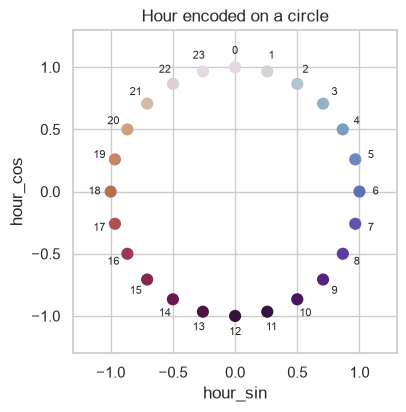

In [5]:
# ขั้น 5.4 — พิสูจน์ว่า sin/cos ทำให้ 23:00 กับ 0:00 อยู่ใกล้กันจริง (ตัวเลขดิบ 0–23 บอกว่าห่างกัน 23)
def circle_dist(a, b):
    # ระยะแบบยุคลิดระหว่างชั่วโมง a กับ b เมื่อวางบนวงกลม (sin, cos)
    return np.hypot(np.sin(2 * np.pi * a / 24) - np.sin(2 * np.pi * b / 24),
                    np.cos(2 * np.pi * a / 24) - np.cos(2 * np.pi * b / 24))


pairs = [(23, 0), (0, 1), (22, 2), (0, 12), (6, 18)]
dist_table = pd.DataFrame([{"คู่ชั่วโมง": f"{a}:00 - {b}:00", "|ต่าง| แบบตัวเลข 0-23": abs(a - b),
                            "ระยะบนวงกลม (sin, cos)": round(circle_dist(a, b), 3)} for a, b in pairs])
print(dist_table.to_string(index=False))

# วาด 24 ชั่วโมงบนวงกลม → เห็นว่าไม่มี "รอยต่อ" ระหว่าง 23 กับ 0
h = np.arange(24)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24), c=h, cmap="twilight", s=60)
for i in h:
    ax.annotate(str(i), (1.13 * np.sin(2 * np.pi * i / 24), 1.13 * np.cos(2 * np.pi * i / 24)), ha="center", va="center", fontsize=8)
ax.set(xlabel="hour_sin", ylabel="hour_cos", title="Hour encoded on a circle", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal")
savefig("05_hour_cyclic.png")
plt.show()

**ผลลัพธ์:**
- แบบตัวเลขดิบ 23:00 กับ 0:00 ห่างกัน **23** (ไกลที่สุดที่เป็นไปได้) ทั้งที่ห่างกันจริงแค่ 1 ชั่วโมง · แบบวงกลมได้ **0.261** เท่ากับคู่ 0:00–1:00 พอดี
- 22:00–2:00 (ห่างจริง 4 ชม.) ตัวเลขดิบบอก 20 แต่วงกลมบอก 1.0 · คู่ที่ห่างกันครึ่งวัน (0–12, 6–18) ได้ระยะมากสุด = 2 (เส้นผ่านศูนย์กลาง)
- กราฟวงกลมแสดงว่าทุกชั่วโมงเรียงต่อกันเป็นวง ไม่มี "รอยต่อ" ระหว่าง 23 กับ 0

**ข้อจำกัดของ sin/cos:** แก้ปัญหา "ระยะ" ได้ แต่สำหรับ **โมเดลเชิงเส้น** ผลรวม $a\cdot\text{hour\_sin} + b\cdot\text{hour\_cos}$ เป็นคลื่นที่มี **สูงสุดได้แค่ 1 ครั้งต่อวัน** ในขณะที่ยอดเช่าวันทำงานมี **2 พีค** (8:00 และ 18:00 — `01_eda` 4.5) → โมเดลเชิงเส้นจับรูปร่างนี้ไม่ได้ด้วย sin/cos อย่างเดียว

**ตัดสินใจ:** เก็บ encoding ของชั่วโมงไว้ 3 แบบ เลือกผ่านพารามิเตอร์ `hour=` ของ Pipeline (ขั้น 6) แล้วให้ CV ในขั้น 10 ตัดสิน
| โมเดล | `hour=` ที่คาดว่าเหมาะ | เหตุผล |
|---|---|---|
| Linear Regression / Lasso | `"onehot"` (24 คอลัมน์) | ให้แต่ละชั่วโมงมีค่าคงที่ของตัวเอง → รองรับ 2 พีคได้ |
| kNN | `"cyclic"` | ใช้ระยะทาง → ต้องการให้ 23:00 ใกล้ 0:00 และจำนวนคอลัมน์น้อย |
| Random Forest / Gradient Boosting | `"raw"` (0–23) | ต้นไม้ตัดแบ่ง `hour ≤ 7.5` ได้ตรงๆ หลายครั้ง จับ 2 พีคได้เอง |

### 5.5 กำหนด y (regression)
**โค้ดทำอะไร:**
- `y` = `rented_bike_count` ดิบ (คัน/ชม.) ไม่แปลงค่าใดๆ — label มากับ dataset อยู่แล้ว
- `y_test` แยกเก็บไว้เฉยๆ **ไม่พิมพ์/ไม่ดูค่า** จนถึงขั้น 13
- ดูสถิติของ `y_train` ทั้งหมดและแยกฤดู เพื่อรู้ "สเกล" ของ MAE ที่จะได้ (MAE 100 คัน ดีแค่ไหนขึ้นกับว่ายอดปกติเป็นหลักร้อยหรือหลักพัน)

In [6]:
# ขั้น 5.5 — กำหนด target y = จำนวนจักรยานที่ถูกเช่าต่อชั่วโมง (regression)
assert config.TASK == "regression"
y_train = train[config.TARGET_COL]
y_test = test[config.TARGET_COL]      # ไม่ดูค่าใดๆ ของ test จนถึงขั้น 13

print(f"y_train: {len(y_train):,} ค่า | mean = {y_train.mean():.1f} | median = {y_train.median():.1f} | "
      f"min = {y_train.min()} | max = {y_train.max()} คัน/ชม.")
print()
print("ค่าเฉลี่ย y_train แยกฤดู (คัน/ชม.):")
print(y_train.groupby(train["seasons"]).mean().round(1).sort_values().to_dict())

y_train: 6,768 ค่า | mean = 756.8 | median = 582.5 | min = 2 | max = 3556 คัน/ชม.

ค่าเฉลี่ย y_train แยกฤดู (คัน/ชม.):
{'Winter': 230.3, 'Spring': 773.9, 'Autumn': 957.5, 'Summer': 1037.4}


**ผลลัพธ์:**
- `y_train` 6,768 ค่า · mean = **756.8** · median = **582.5** · ช่วง 2–3,556 คัน/ชม. (ตรงกับ `01_eda` 4.4)
- ค่าเฉลี่ยแยกฤดู: Winter **230** · Spring 774 · Autumn 958 · Summer **1,037** คัน/ชม. → ต่างกันเกือบ 4.5 เท่า
  → `seasons`/`temp_c` จะเป็น feature ที่แรงมาก และค่าคลาดเคลื่อนเป็นคันของฤดูหนาวจะเล็กตามสเกล

**ผลต่อขั้นถัดไป:**
- เมตริกหลัก MAE (ขั้น 1) → ใน CV ใช้ `scoring="neg_mean_absolute_error"` (sklearn ให้ค่าติดลบเพื่อให้ "มากกว่า = ดีกว่า" ต้องกลับเครื่องหมายตอนรายงาน) คู่กับ `"neg_root_mean_squared_error"` และ `"r2"`
- เพราะ MAE ขึ้นกับสเกลของแต่ละฤดู ต้องรายงาน MAE แยกฤดูในขั้น error analysis (test มีฤดูหนาวมากกว่า train — `01_eda` 3.2)

### 5.6 ประกอบ X, y, groups + ตรวจ leakage
**โค้ดทำอะไร:**
- ตัดคอลัมน์ที่ห้ามเป็น feature ออกจาก X: `rented_bike_count` (target), `date` (ใช้เป็น `groups` แทน), `functioning_day` (หลังตัดเหลือค่าเดียว), `holiday` (ข้อความ แทนด้วย `is_holiday` แล้ว)
- `groups_train` = วันที่ของแต่ละแถวใน train → ใช้กับ `GroupKFold` ในทุกขั้นที่มี CV
- `assert` กัน leakage

In [7]:
# ขั้น 5.6 — ประกอบ X, y, groups และตรวจ leakage ก่อนเข้าโมเดล
# ตัดคอลัมน์ที่ห้ามเป็น feature: target เอง, date (ใช้เป็น group), functioning_day (ถูกกรองแล้ว), holiday (แปลงเป็น is_holiday แล้ว)
NOT_FEATURES = [config.TARGET_COL, "date", "functioning_day", "holiday"]
FEATURES = [c for c in train.columns if c not in NOT_FEATURES]

X_train, X_test = train[FEATURES], test[FEATURES]
groups_train = train["date"]          # บอก GroupKFold ว่าแถวไหนเป็นวันเดียวกัน → วันเดียวกันอยู่ fold เดียวกัน

assert config.TARGET_COL not in X_train.columns and "date" not in X_train.columns
assert list(X_train.columns) == list(X_test.columns)
assert len(X_train) == len(y_train) == len(groups_train)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | groups: {groups_train.nunique()} วัน")
print(f"X_test : {X_test.shape}")
print("features:", FEATURES)
X_train.dtypes.value_counts()

X_train: (6768, 17) | y_train: (6768,) | groups: 282 วัน
X_test : (1697, 17)
features: ['hour', 'temp_c', 'humidity_pct', 'wind_speed_ms', 'visibility_10m', 'dew_point_c', 'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'seasons', 'day_of_week', 'is_weekend', 'is_holiday', 'month', 'hour_sin', 'hour_cos', 'is_raining']


float64    9
int64      5
int32      2
object     1
Name: count, dtype: int64

**ผลลัพธ์:**
- X_train **6,768 × 17** (feature ดิบ 10 ตัว + ใหม่ 7 ตัว) · X_test 1,697 × 17 คอลัมน์ชุดเดียวกัน · groups = 282 วัน
- 17 feature: `hour`, อากาศ 8 ตัว, `seasons` + 7 ตัวที่สร้างใหม่ · มี `seasons` เป็น object ตัวเดียว ที่เหลือเป็นตัวเลข
- ยังไม่มีการ scale/encode ใดๆ ในขั้นนี้ — ทุกอย่างที่ "เรียนจากข้อมูล" จะอยู่ใน Pipeline (ขั้น 6)

**เช็คลิสต์ leakage ที่ผ่านแล้วในขั้น 5**
- [x] y = ยอดเช่าดิบ ไม่มีการแปลงที่เรียนค่าจากข้อมูล (ถ้าจะลอง `log1p` ในขั้น 11 จะอยู่ใน `TransformedTargetRegressor` ซึ่ง fit ใหม่ทุก fold)
- [x] `rented_bike_count` ไม่อยู่ใน X
- [x] ไม่มี feature ที่คำนวณจาก target (ทุก feature มาจากแถวเดียวกันและไม่แตะยอดเช่า)
- [x] ไม่ได้ดูค่าใดๆ ของ test นอกจากจำนวนแถว

---
## ขั้น 6 — Preprocessing ใน Pipeline

**หลักการ:** ทุกขั้นที่ "เรียนค่าจากข้อมูล" (ค่ามัธยฐานของ imputer, mean/std ของ scaler, รายการหมวดหมู่ของ encoder และต่อไปคือ selector, PCA) ต้องอยู่ใน `Pipeline`
เพราะตอน `cross_validate(pipe, ..., cv=GroupKFold)` sklearn จะ `fit` ทั้ง pipeline ใหม่บน training fold แล้วค่อย `transform` validation fold → ค่าสถิติไม่รั่วจาก validation เข้ามา
ถ้า scale ทั้ง train ก่อนแล้วค่อย CV → mean/std มีข้อมูลของ validation fold ปนอยู่ = leakage (เล็กแต่มีจริง)

### 6.1 แบ่งกลุ่มคอลัมน์
**โค้ดทำอะไร:** กำหนดว่าแต่ละคอลัมน์จะถูกจัดการแบบไหน

| กลุ่ม | คอลัมน์ | การแปลง | เหตุผล |
|---|---|---|---|
| ตัวเลข (อากาศ) | 8 ตัว | median imputer → StandardScaler | `humidity_pct` มี missing value 17 ค่า (ความชื้น 0% จาก `01_eda` 4.11) → เติมด้วย median · สเกลต่างกันมาก (visibility 27–2,000) |
| ชั่วโมง (cyclic) | `hour_sin`, `hour_cos` | StandardScaler | ให้อยู่สเกลเดียวกับตัวอื่น |
| binary | `is_weekend`, `is_holiday`, `is_raining` | StandardScaler | ให้ L1 (ขั้น 7) ลงโทษทุก feature ในสเกลเดียวกัน และ kNN ให้น้ำหนักเท่ากัน |
| หมวดหมู่ | `seasons`, `month`, `day_of_week` | OneHotEncoder | ไม่มีลำดับเชิงตัวเลขที่มีความหมาย (เดือน 12 ไม่ได้ "มากกว่า" เดือน 1 และธ.ค. อยู่ติด ม.ค.) |

In [8]:
# ขั้น 6.1 — แบ่งคอลัมน์ตามวิธี preprocess ที่ต้องใช้ (ตัวเลข → impute + scale · หมวดหมู่ → one-hot)
WEATHER_COLS = ["temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m", "dew_point_c",
                "solar_radiation_mj", "rainfall_mm", "snowfall_cm"]
CYCLIC_COLS = ["hour_sin", "hour_cos"]
BINARY_COLS = ["is_weekend", "is_holiday", "is_raining"]
CAT_COLS = ["seasons", "month", "day_of_week"]   # หมวดหมู่ที่ไม่มีลำดับ → one-hot ไม่ใช่ label encoding

grouped = WEATHER_COLS + CYCLIC_COLS + BINARY_COLS + CAT_COLS
print("ใน X แต่ไม่อยู่ในกลุ่มใด:", sorted(set(FEATURES) - set(grouped)))
assert set(grouped) <= set(FEATURES)

ใน X แต่ไม่อยู่ในกลุ่มใด: ['hour']


**ผลลัพธ์:** ทุกคอลัมน์ในกลุ่มมีอยู่ใน X จริง และเหลือ `hour` (ดิบ) ตัวเดียวที่ไม่อยู่ในกลุ่ม default — ตั้งใจ เพราะใช้ `hour_sin/cos` แทน · `hour` ดิบจะถูกใช้เมื่อเลือก `hour="raw"` หรือ `"onehot"` ในขั้นถัดไป

### 6.2 ฟังก์ชันสร้าง preprocessor และ Pipeline
**โค้ดทำอะไร:**
- `make_preprocessor(hour=...)` สร้าง `ColumnTransformer` ตามตาราง 6.1 โดยเลือกวิธี encode ชั่วโมงได้ 3 แบบ: `"cyclic"` (default), `"raw"` (0–23 ตรงๆ สำหรับ tree), `"onehot"` (24 คอลัมน์)
- `SimpleImputer(strategy="median")` เติม missing value ของความชื้น (17 ค่าจาก `01_eda` 4.11) ด้วยมัธยฐานของ training fold
- `make_pipeline(model, select=..., hour=...)` ต่อเป็น `Pipeline([("pre", ...), ("select", ...), ("model", ...)])`
  - ช่อง `"select"` เป็น `"passthrough"` ไว้ก่อน → ขั้น 7 ใส่ `SelectKBest` / `RFE` / `SelectFromModel` ลงช่องนี้ และขั้น 8 ใส่ PCA
  - ขั้น 10 แค่เปลี่ยน `model` ก็เทียบหลายโมเดลด้วย preprocessing ชุดเดียวกันได้
- `OneHotEncoder(handle_unknown="ignore")`: ถ้า validation/test มีหมวดที่ training fold ไม่เคยเห็น จะได้ศูนย์ทั้งแถวแทนที่จะ error
- `verbose_feature_names_out=False` ให้ชื่อ feature หลังแปลงสั้น อ่านง่าย (เช่น `seasons_Winter` แทน `cat__seasons_Winter`)

In [9]:
# ขั้น 6.2 — ฟังก์ชันสร้าง preprocessor และ Pipeline
# แนวคิดหลัก: ทุกอย่างที่ "เรียนค่าจากข้อมูล" (median, mean/std, หมวดหมู่) อยู่ใน Pipeline
# → ตอน CV จะ fit ใหม่บน training fold เท่านั้น ข้อมูล validation/test ไม่รั่วเข้าไป
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_preprocessor(hour="cyclic"):
    # hour= เลือกวิธี encode ชั่วโมงตามชนิดโมเดล: cyclic (kNN), raw (tree), onehot (linear)
    hour_num = {"cyclic": CYCLIC_COLS, "raw": ["hour"], "onehot": []}[hour]
    hour_cat = ["hour"] if hour == "onehot" else []
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),   # median ทนต่อค่าสุดโต่งมากกว่า mean
        ("scale", StandardScaler()),                    # Z-score: ให้ทุกตัวแปรมีสเกลเท่ากัน (สำคัญกับ kNN, PCA, Lasso)
    ])
    return ColumnTransformer([
        ("num", numeric, WEATHER_COLS + hour_num + BINARY_COLS),
        # handle_unknown="ignore": ถ้าเจอหมวดที่ไม่เคยเห็นตอนฝึก ให้เป็นศูนย์ทุกคอลัมน์แทนการ error
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS + hour_cat),
    ], verbose_feature_names_out=False)


def make_pipeline(model, select="passthrough", hour="cyclic"):
    # 3 ช่อง: preprocess → select (feature selection หรือ PCA, ขั้น 7–8) → model
    return Pipeline([
        ("pre", make_preprocessor(hour)),
        ("select", select),
        ("model", model),
    ])


# ตัวอย่างโครงสร้าง (model จริงเลือกในขั้น 9-10)
from sklearn.linear_model import LinearRegression
make_pipeline(LinearRegression())

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['temp_c', 'humidity_pct',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_c',
                                                   'solar_radiation_mj',
                                                   'rainfall_mm', 'snowfall_cm',
                                                   'hour_sin', 'hour_cos',
                                                   'is_weekend', 'i

**ผลลัพธ์:** โครงสร้าง Pipeline มี 3 ช่องตามที่ออกแบบ: `pre` (ColumnTransformer: `num` = imputer → scaler, `cat` = one-hot) → `select` (passthrough) → `model`
LinearRegression ในที่นี้เป็นแค่ตัวอย่างให้เห็นโครงสร้าง ยังไม่ได้ fit

### 6.3 ตรวจผลลัพธ์ของ preprocessor
**โค้ดทำอะไร:** `fit_transform` preprocessor บน X_train ทั้งก้อน **เพื่อตรวจความถูกต้องเท่านั้น** (ขั้นประเมินจริงใช้ CV ที่ fit ใหม่ในแต่ละ fold)
- จำนวนคอลัมน์หลังแปลง + รายชื่อ
- มี NaN เหลือไหม, ค่ามัธยฐานที่ imputer ใช้เติมความชื้น
- คอลัมน์ตัวเลขหลัง scale ต้องมี mean ≈ 0, std ≈ 1 · one-hot ของแต่ละกลุ่มต้องรวมกันได้ 1 ทุกแถว

In [10]:
# ขั้น 6.3 — ลอง fit preprocessor บน train แล้วตรวจผล: ไม่มี NaN เหลือ, one-hot ถูก, ตัวเลขถูก standardize
pre = make_preprocessor()
Xt = pd.DataFrame(pre.fit_transform(X_train), columns=pre.get_feature_names_out(), index=X_train.index)

num_out = WEATHER_COLS + CYCLIC_COLS + BINARY_COLS
imputer = pre.named_transformers_["num"].named_steps["impute"]
print(f"shape หลังแปลง: {Xt.shape} | NaN เหลือ: {int(Xt.isna().sum().sum())}")
print("ค่าที่ใช้เติม humidity_pct (median ของ train):", imputer.statistics_[WEATHER_COLS.index("humidity_pct")])
# one-hot ที่ถูกต้อง: แต่ละแถวต้องมีเลข 1 แค่ช่องเดียวในกลุ่มของมัน
for c in CAT_COLS:
    cols = [n for n in Xt.columns if n.startswith(c + "_")]
    print(f"{c:<12} -> {len(cols):>2} คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: {bool((Xt[cols].sum(axis=1) == 1).all())}")
print("\nfeature หลังแปลง:", list(Xt.columns))
Xt[num_out].agg(["mean", "std"]).T.round(3).T     # หลัง StandardScaler: mean ≈ 0, std ≈ 1

shape หลังแปลง: (6768, 36) | NaN เหลือ: 0
ค่าที่ใช้เติม humidity_pct (median ของ train): 57.0
seasons      ->  4 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True
month        -> 12 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True
day_of_week  ->  7 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True

feature หลังแปลง: ['temp_c', 'humidity_pct', 'wind_speed_ms', 'visibility_10m', 'dew_point_c', 'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'is_raining', 'seasons_Autumn', 'seasons_Spring', 'seasons_Summer', 'seasons_Winter', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']


,temp_c,humidity_pct,wind_speed_ms,visibility_10m,dew_point_c,solar_radiation_mj,rainfall_mm,snowfall_cm,hour_sin,hour_cos,is_weekend,is_holiday,is_raining
mean,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**ผลลัพธ์:**
- ได้ **36 คอลัมน์**: ตัวเลข 13 (อากาศ 8 + ชั่วโมง 2 + binary 3) + one-hot 23 (`seasons` 4 + `month` 12 + `day_of_week` 7) · ไม่มี NaN เหลือ
- missing value ของความชื้น 17 ค่า (จาก 5.1) ถูกเติมด้วยมัธยฐานของ train = **57%**
- one-hot ทุกกลุ่มรวมกันได้ 1 ทุกแถว (แต่ละแถวอยู่ในฤดู/เดือน/วันเดียวพอดี)
- คอลัมน์ตัวเลข 13 ตัวมี mean = 0.000 และ std = 1.000 → StandardScaler ทำงานถูกต้อง (สเกลของ visibility กับ rainfall เท่ากันแล้ว)
- ⚠️ one-hot ของ `seasons` กับ `month` ซ้อนกันสมบูรณ์ (รู้เดือน = รู้ฤดู) และแต่ละกลุ่ม one-hot รวมกันได้ 1 เท่ากับ intercept → **multicollinearity สมบูรณ์** สำหรับ Linear Regression ที่ไม่มี regularization: ค่าทำนายยังใช้ได้ (sklearn แก้ด้วย least squares แบบ minimum-norm) แต่ **coefficient ไม่มีคำตอบเดียว จึงตีความไม่ได้** → เป็นเหตุผลที่ต้องทำ feature selection ในขั้น 7 (เลือก `seasons` หรือ `month` อย่างใดอย่างหนึ่ง) และใช้ Lasso ซึ่งมี regularization

### 6.4 พิสูจน์ว่า Pipeline + GroupKFold ไม่รั่ว
**โค้ดทำอะไร:** จำลองสิ่งที่ `cross_validate` จะทำในขั้น 10 ทีละ fold ด้วย `GroupKFold(n_splits=5)` + `groups=groups_train`
- นับวันที่อยู่ทั้งใน training fold และ validation fold (ต้องเป็น 0)
- fit preprocessor ใหม่บน training fold แล้วดูค่าที่มัน "เรียน" (mean ของ `temp_c` ใน scaler, median ความชื้นใน imputer) → ต้อง **ต่างกันในแต่ละ fold** = แต่ละ fold เรียนจากข้อมูลของตัวเองเท่านั้น
- เทียบกับ `KFold` ธรรมดา (สุ่มทีละแถว ไม่ส่ง groups) ว่ามีวันซ้ำกี่วัน

In [11]:
# ขั้น 6.4 — พิสูจน์ว่า Pipeline + GroupKFold ไม่รั่ว โดยจำลองสิ่งที่ cross_validate ทำทีละ fold
from sklearn.model_selection import GroupKFold, KFold

cv = GroupKFold(n_splits=5)   # ใช้ตัวนี้ในทุกขั้นที่มี CV (ขั้น 7-11) และต้องส่ง groups= ทุกครั้ง

rows = []
for k, (tr, va) in enumerate(cv.split(X_train, y_train, groups=groups_train)):
    p = make_preprocessor().fit(X_train.iloc[tr])     # fit ใหม่บน training fold เท่านั้น
    num = p.named_transformers_["num"]
    rows.append({
        "fold": k,
        "train วัน": groups_train.iloc[tr].nunique(),
        "val วัน": groups_train.iloc[va].nunique(),
        "วันซ้ำ train-val": len(set(groups_train.iloc[tr]) & set(groups_train.iloc[va])),   # ต้องเป็น 0
        # ค่าที่ preprocessor เรียนได้ต่างกันในแต่ละ fold = แต่ละ fold เรียนจากข้อมูลของตัวเอง
        "scaler mean temp_c": num.named_steps["scale"].mean_[WEATHER_COLS.index("temp_c")],
        "imputer median humidity": num.named_steps["impute"].statistics_[WEATHER_COLS.index("humidity_pct")],
        "y เฉลี่ยใน val": y_train.iloc[va].mean(),
    })
fold_table = pd.DataFrame(rows).set_index("fold").round(3)

# เทียบกับ KFold ธรรมดา (สุ่มทีละแถว ไม่ส่ง groups) → ชั่วโมงของวันเดียวกันไปอยู่ทั้ง train และ val
tr, va = next(KFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE).split(X_train))
leak_days = len(set(groups_train.iloc[tr]) & set(groups_train.iloc[va]))
print(f"KFold ธรรมดา fold 0: val มี {groups_train.iloc[va].nunique()} วัน -> ซ้ำกับ train {leak_days} วัน")
fold_table

KFold ธรรมดา fold 0: val มี 281 วัน -> ซ้ำกับ train 281 วัน


,train วัน,val วัน,วันซ้ำ train-val,scaler mean temp_c,imputer median humidity,y เฉลี่ยใน val
fold,,,,,,
0,225,57,0,13.395,57.0,783.931
1,225,57,0,13.385,57.0,719.159
2,226,56,0,13.348,58.0,772.452
3,226,56,0,13.362,58.0,778.076
4,226,56,0,13.395,57.0,730.462


**ผลลัพธ์:**
- `GroupKFold`: ทุก fold มี **วันซ้ำ train-val = 0** · แต่ละ fold ใช้ 225–226 วัน train / 56–57 วัน validation
- ค่า mean ของ `temp_c` ที่ scaler เรียนได้ **ต่างกันในแต่ละ fold** (13.35–13.40 °C) → ยืนยันว่า preprocessor ถูก fit ใหม่จากข้อมูลของ fold นั้นๆ ไม่ได้เห็น validation (ต่างกันน้อยเพราะแต่ละ fold มีข้อมูล 80% ของ train)
- median ความชื้นที่ imputer เรียนได้ 57 หรือ 58% แล้วแต่ fold
- ยอดเช่าเฉลี่ยของแต่ละ validation fold อยู่ระหว่าง **719–784 คัน/ชม.** (ไม่เท่ากับ 756.8 ของ train ทุก fold เพราะแต่ละ fold ได้วันต่างฤดูกัน) — ความต่างนี้จะสะท้อนเป็น std ของ MAE ใน CV ขั้น 10
- **`KFold` ธรรมดา**: validation fold 0 มีแถวจาก 281 วัน และ **ทั้ง 281 วันมีชั่วโมงอื่นของวันเดียวกันอยู่ใน train** → ทุกวันใน validation มีชั่วโมงข้างเคียงอยู่ใน train = leakage แบบที่อธิบายในขั้น 3 · นี่คือเหตุผลที่ต้องใช้ `GroupKFold` + `groups=` เสมอ

### 6.5 โมเดลไหนต้อง scale
| model family | ต้อง scale ไหม | เพราะ |
|---|---|---|
| kNN, SVR | **ต้อง** | ใช้ระยะทาง → คอลัมน์สเกลใหญ่ (visibility 27–2,000) ครอบงำระยะ |
| Lasso / Ridge | **ต้อง** | regularization ลงโทษขนาด coefficient ซึ่งขึ้นกับสเกลของ feature → ไม่ scale = ลงโทษไม่เท่ากัน |
| Linear Regression (ไม่มี regularization) | ไม่จำเป็นต่อค่าทำนาย | ค่าทำนายเท่าเดิม แต่ต้อง scale ถ้าจะเทียบขนาด coefficient ว่า feature ไหนสำคัญกว่า |
| Decision Tree, Random Forest, Gradient Boosting | ไม่จำเป็น | ตัดแบ่งทีละ feature ด้วย threshold → การ scale แบบ monotonic ไม่เปลี่ยนลำดับค่า ผลเหมือนเดิม |

→ ใส่ scaler ไว้ในทุก pipeline (ไม่เสียหายกับ tree และทำให้ทุกโมเดลได้ input ชุดเดียวกัน เทียบกันได้ยุติธรรม)

---
### สรุปขั้น 5–6 (สิ่งที่ส่งต่อไปขั้น 7+)
| ตัวแปร / ฟังก์ชัน | คืออะไร |
|---|---|
| `X_train`, `y_train`, `groups_train` | 6,768 แถว × 17 feature, y = `rented_bike_count` (คัน/ชม.), วันที่สำหรับ GroupKFold |
| `X_test`, `y_test` | 1,697 แถว — **ห้ามใช้จนถึงขั้น 13** |
| `make_pipeline(model, select, hour)` | Pipeline มาตรฐาน: imputer + scaler + one-hot → ช่อง select → model |
| `cv` | `GroupKFold(n_splits=5)` — ใช้คู่กับ `groups=groups_train` เสมอ |

**เช็คลิสต์ leakage (สถานะหลังขั้น 6)**
- [x] split ตามวัน และ CV ใช้ `GroupKFold` + ส่ง `groups=`
- [x] y = ยอดเช่าดิบ (ไม่มี threshold / การแปลงที่เรียนจากข้อมูล)
- [x] `rented_bike_count` ไม่อยู่ใน X
- [x] imputer / scaler / encoder อยู่ใน Pipeline (selector / PCA จะใส่ในช่อง `select` ขั้น 7–8)
- [x] ไม่มี feature ที่คำนวณจาก target
- [x] ไม่ได้เปิด test ระหว่างขั้น 4–6

---
## ขั้น 7 — Feature selection 3 แบบ

**หลักการ:** selector ทุกตัวอยู่ในช่อง `select` ของ Pipeline และเลือกจำนวน feature / ค่า alpha ด้วย `GridSearchCV` + `GroupKFold` + `groups` → การเลือก feature ถูกทำใหม่ในทุก fold จากข้อมูล training fold เท่านั้น
ประเมินด้วย **Linear Regression + `hour="onehot"`** (58 คอลัมน์) เพราะ feature selection มีผลกับโมเดลเชิงเส้นมากที่สุด ส่วน tree-based เลือก feature ที่ใช้ตัดแบ่งเองอยู่แล้ว

### 7.0 ฟังก์ชันช่วย + จุดอ้างอิง (ทุก feature)
**โค้ดทำอะไร:**
- `cv_report(pipe, name)` = `cross_validate` ด้วย `cv` + `groups=groups_train` แล้วคืน MAE (mean ± std) / MSE / RMSE / R² + MAE บน train + เวลา fit — ใช้ซ้ำทุกขั้นจากนี้
- `grid(pipe, params)` = `GridSearchCV` ที่ตั้งค่าเหมือนกันทุกครั้ง (`GroupKFold`, `groups`, เลือกด้วย MAE)
- วัด Linear Regression ที่ใช้ทุก feature เป็นจุดอ้างอิงของขั้นนี้

In [12]:
# ขั้น 7.0 — ฟังก์ชันช่วยที่ใช้ซ้ำทุกขั้นจากนี้ + จุดอ้างอิง (Linear Regression ใช้ทุก feature)
import time
from functools import partial

from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, cross_validate

# วัดครบ 4 metric ของ regression ตามโจทย์ · sklearn ให้คะแนนแบบ "ยิ่งมากยิ่งดี" จึงเป็นค่าติดลบ (ต้องกลับเครื่องหมาย)
SCORING = {"MAE": "neg_mean_absolute_error", "MSE": "neg_mean_squared_error",
           "RMSE": "neg_root_mean_squared_error", "R2": "r2"}


def cv_report(pipe, name):
    """cross_validate ด้วย GroupKFold + groups แล้วคืน 1 แถว: mean ± std ของ MAE, mean ของ MSE/RMSE/R², MAE บน train, เวลา fit"""
    # return_train_score=True → ได้ MAE บน training fold ด้วย ใช้เทียบหา overfit (gap = CV − train)
    s = cross_validate(pipe, X_train, y_train, groups=groups_train, cv=cv, scoring=SCORING,
                       return_train_score=True, n_jobs=-1)
    return {
        "model": name,
        "MAE": -s["test_MAE"].mean(), "MAE_std": s["test_MAE"].std(),
        "MSE": -s["test_MSE"].mean(), "RMSE": -s["test_RMSE"].mean(), "R2": s["test_R2"].mean(),
        "MAE_train": -s["train_MAE"].mean(), "fit_s": s["fit_time"].mean(),
    }


def grid(pipe, param_grid):
    """GridSearchCV แบบเดียวกันทุกขั้น: GroupKFold + groups, เลือกด้วย MAE"""
    # เลือกพารามิเตอร์ด้วย CV บน train เท่านั้น — test ยังไม่ถูกแตะ
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    return gs.fit(X_train, y_train, groups=groups_train)


# FS มีผลกับโมเดลเชิงเส้นมากที่สุด จึงใช้ Linear Regression + hour one-hot เป็นตัวประเมินทุกวิธีในขั้น 7
base_lin = cv_report(make_pipeline(LinearRegression(), hour="onehot"), "Linear (ทุก feature)")
n_all = make_preprocessor("onehot").fit(X_train).get_feature_names_out().size
print(f"จำนวน feature หลัง preprocess (hour one-hot): {n_all}")
print(f"Linear Regression ทุก feature: CV MAE = {base_lin['MAE']:.1f} ± {base_lin['MAE_std']:.1f} คัน/ชม. | MAE บน train = {base_lin['MAE_train']:.1f} | R² = {base_lin['R2']:.3f}")

จำนวน feature หลัง preprocess (hour one-hot): 58
Linear Regression ทุก feature: CV MAE = 266.2 ± 4.8 คัน/ชม. | MAE บน train = 259.8 | R² = 0.713


**ผลลัพธ์:**
- หลัง preprocess แบบ `hour="onehot"` มี **58 คอลัมน์** (ตัวเลข 11 + one-hot ของ seasons 4, month 12, day_of_week 7, hour 24)
- Linear Regression ทุก feature: CV MAE = **266.2 ± 4.8** คัน/ชม. · MAE บน train = 259.8 → ต่างกันแค่ ~6 คัน = **ไม่ overfit**
  → feature selection มักช่วยเมื่อ feature เยอะจน overfit แต่ที่นี่แถวมี 6,768 เทียบกับ 58 คอลัมน์ จึงคาดว่า FS จะไม่ทำให้ MAE ดีขึ้นมาก — ประโยชน์หลักคือ "ตัด feature ซ้ำซ้อน" และ "ดูว่า feature ไหนสำคัญ"

### 7.1 Filter — `f_regression` และ `mutual_info_regression`
| วิธี | วัดอะไร | จุดอ่อน |
|---|---|---|
| `f_regression` | F-statistic ของความสัมพันธ์ **เชิงเส้น** ระหว่างแต่ละ feature กับ y | มองไม่เห็นความสัมพันธ์โค้ง |
| `mutual_info_regression` | ข้อมูลร่วม (ความสัมพันธ์ **แบบใดก็ได้**) | ช้ากว่า มีการสุ่ม (ตั้ง `random_state`) |

- ⚠️ **ใช้ `chi2` (ที่ตัวอย่างในโจทย์ใช้) ไม่ได้** — chi² ต้องการ target เป็นหมวดหมู่ ส่วน y ของเราเป็นจำนวนต่อเนื่อง
- ทั้งสองวิธีให้คะแนน feature **ทีละตัว** แล้ว `SelectKBest` เก็บ `k` ตัวที่คะแนนสูงสุด · ลอง k = 5, 10, 15, 20, 30, 40, 58

CV MAE (คัน/ชม.) ตามจำนวน feature ที่เลือก (k):
    f_regression  mutual_info
k                            
5          364.1        367.2
10         350.9        354.1
15         318.6        336.0
20         303.5        310.1
30         278.9        291.1
40         269.3        276.2
58         266.2        266.2
f_regression  best k = 58 | MAE = 266.2
mutual_info   best k = 58 | MAE = 266.2


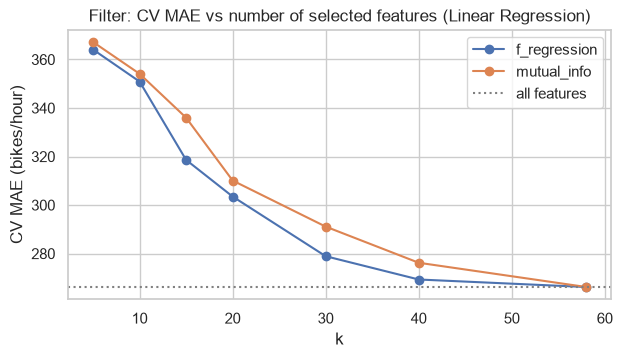

In [13]:
# ขั้น 7.1 — Filter: ให้คะแนน feature ทีละตัวด้วยสถิติ แล้วเก็บ k ตัวที่คะแนนสูงสุด
# ใช้ f_regression (ความสัมพันธ์เชิงเส้น) และ mutual_info (ความสัมพันธ์แบบใดก็ได้) แทน chi² ซึ่งใช้ได้กับ target หมวดหมู่เท่านั้น
K_GRID = [5, 10, 15, 20, 30, 40, n_all]
mi = partial(mutual_info_regression, random_state=config.RANDOM_STATE)   # MI มีการสุ่ม → ตรึง seed
# selector อยู่ในช่อง select ของ Pipeline → เลือก feature ใหม่ทุก fold จาก training fold เท่านั้น
filters = {
    "f_regression": grid(make_pipeline(LinearRegression(), select=SelectKBest(f_regression), hour="onehot"), {"select__k": K_GRID}),
    "mutual_info": grid(make_pipeline(LinearRegression(), select=SelectKBest(mi), hour="onehot"), {"select__k": K_GRID}),
}
k_table = pd.DataFrame({name: -gs.cv_results_["mean_test_score"] for name, gs in filters.items()}, index=K_GRID).round(1)
k_table.index.name = "k"
print("CV MAE (คัน/ชม.) ตามจำนวน feature ที่เลือก (k):")
print(k_table)
for name, gs in filters.items():
    print(f"{name:<13} best k = {gs.best_params_['select__k']:>2} | MAE = {-gs.best_score_:.1f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
k_table.plot(ax=ax, marker="o")
ax.axhline(base_lin["MAE"], color="gray", ls=":", label="all features")
ax.set(title="Filter: CV MAE vs number of selected features (Linear Regression)", xlabel="k", ylabel="CV MAE (bikes/hour)")
ax.legend()
savefig("07_filter_k.png")
plt.show()

**ผลลัพธ์:**
- ทั้งสองวิธีได้ **best k = 58 (ใช้ทุกตัว)** · MAE ลดลงต่อเนื่องเมื่อ k เพิ่ม: k=5 → 364.1 / 367.2 · k=30 → 278.9 / 291.1 · k=40 → 269.3 / 276.2
- เหตุผล: filter ให้คะแนนทีละคอลัมน์ แต่ one-hot ของชั่วโมง (24 คอลัมน์) มีประโยชน์ **เมื่ออยู่ด้วยกัน** (สร้างรูปร่าง 2 พีค) — `hour_3` เดี่ยวๆ สัมพันธ์กับ y น้อย แต่ถ้าตัดทิ้ง โมเดลจะไม่รู้ว่าตี 3 ยอดต่ำ
- `f_regression` ดีกว่า `mutual_info` เล็กน้อยทุก k ที่ < 58 เพราะโมเดลปลายทางเป็นเชิงเส้น (เลือกด้วยเกณฑ์เดียวกับที่โมเดลใช้)

**โค้ดทำอะไร (ถัดไป):** คำนวณคะแนนของทั้งสองวิธีบน train ทั้งก้อน **เพื่ออธิบายเท่านั้น** (ไม่ได้ใช้เลือก feature ให้โมเดล) แล้วดู 10 อันดับแรก

In [14]:
# ขั้น 7.1 (ต่อ) — ดูว่าแต่ละวิธีจัด feature ไหนเป็น 10 อันดับแรก
# คำนวณบน train ทั้งก้อนเพื่ออธิบายเท่านั้น ไม่ได้ใช้เลือก feature ให้โมเดล (การเลือกจริงทำใน CV ด้านบน)
pre_oh = make_preprocessor("onehot").fit(X_train)
Xt_oh = pd.DataFrame(pre_oh.transform(X_train), columns=pre_oh.get_feature_names_out())
f_scores = pd.Series(f_regression(Xt_oh, y_train)[0], index=Xt_oh.columns)   # [0] = F-statistic
mi_scores = pd.Series(mi(Xt_oh, y_train), index=Xt_oh.columns)
top = pd.DataFrame({
    "f_regression": f_scores.sort_values(ascending=False).index[:10],
    "F": f_scores.sort_values(ascending=False).values[:10].round(0),
    "mutual_info": mi_scores.sort_values(ascending=False).index[:10],
    "MI": mi_scores.sort_values(ascending=False).values[:10].round(3),
}, index=range(1, 11))
print("10 อันดับแรกของแต่ละวิธี (คำนวณบน train ทั้งก้อน เพื่ออธิบายเท่านั้น):")
print(top.to_string())

10 อันดับแรกของแต่ละวิธี (คำนวณบน train ทั้งก้อน เพื่ออธิบายเท่านั้น):
          f_regression       F         mutual_info     MI
1               temp_c  2945.0              temp_c  0.377
2       seasons_Winter  1737.0  solar_radiation_mj  0.199
3          dew_point_c  1142.0         dew_point_c  0.190
4   solar_radiation_mj   567.0      seasons_Winter  0.189
5              hour_18   548.0        humidity_pct  0.098
6       seasons_Summer   499.0             month_1  0.083
7              month_1   466.0          is_raining  0.074
8             month_12   390.0         rainfall_mm  0.073
9           is_raining   386.0      visibility_10m  0.063
10             month_6   370.0      seasons_Summer  0.056


**ผลลัพธ์:**
- ทั้งสองวิธีจัด **`temp_c` เป็นอันดับ 1** (F = 2,945 · MI = 0.377) ตรงกับ correlation ใน `01_eda` 4.9
- `f_regression` ให้ `seasons_Winter` อันดับ 2 และ `hour_18` (พีคเย็น) อันดับ 5 · `mutual_info` ให้ `solar_radiation_mj` อันดับ 2, `humidity_pct` อันดับ 5 และมี `is_raining`, `rainfall_mm` ติด 10 อันดับ
  → MI จับผลของฝนที่เป็นแบบ "มี/ไม่มี" (zero-inflated, `01_eda` 4.8) ได้ ซึ่ง F-test แบบเส้นตรงให้คะแนนต่ำกว่า

### 7.2 Wrapper — RFE
**โค้ดทำอะไร:** `RFE` fit โมเดล → ตัด feature ที่ |coefficient| เล็กที่สุดทิ้งทีละ 2 ตัว (`step=2`) → fit ใหม่ วนจนเหลือ `n_features_to_select` ตัว · ลอง n = 5, 10, 15, 20, 30, 40, 58 แล้วให้ Linear Regression ทำนายจาก feature ที่เหลือ
- ใช้ **`Ridge(alpha=1.0)`** เป็นตัวจัดอันดับภายใน RFE แทน Linear Regression เพราะ one-hot ที่ซ้อนกัน (6.3) ทำให้ coefficient ของ Linear Regression ไม่มีคำตอบเดียว → การจัดอันดับด้วย |coefficient| จะไม่มีความหมาย · Ridge เพิ่ม regularization เล็กน้อยให้ coefficient มีค่าเดียวที่แน่นอน

In [15]:
# ขั้น 7.2 — Wrapper (RFE): fit โมเดล → ตัด feature ที่ |coefficient| เล็กสุดทีละ 2 ตัว → fit ใหม่ วนจนเหลือ n ตัว
# ใช้ Ridge จัดอันดับแทน Linear Regression เพราะ one-hot ที่ซ้อนกันทำให้ coefficient ของ Linear ไม่มีคำตอบเดียว
N_GRID = [5, 10, 15, 20, 30, 40, n_all]
rfe = grid(make_pipeline(LinearRegression(), select=RFE(Ridge(alpha=1.0), step=2), hour="onehot"),
           {"select__n_features_to_select": N_GRID})
rfe_mae = pd.Series(-rfe.cv_results_["mean_test_score"], index=N_GRID).round(1)
print("RFE: CV MAE ตามจำนวน feature ที่เก็บไว้")
print(rfe_mae.to_dict())
# best_estimator_ ถูก refit บน train ทั้งหมด → ดูว่า RFE เก็บ/ตัด feature ไหน (support_ = True คือเก็บไว้)
best_rfe = rfe.best_estimator_
kept = best_rfe.named_steps["pre"].get_feature_names_out()[best_rfe.named_steps["select"].support_]
dropped = sorted(set(best_rfe.named_steps["pre"].get_feature_names_out()) - set(kept))
print(f"best n = {rfe.best_params_['select__n_features_to_select']} | MAE = {-rfe.best_score_:.1f}")
print("feature ที่ RFE ตัดทิ้ง:", dropped)

RFE: CV MAE ตามจำนวน feature ที่เก็บไว้
{5: 485.8, 10: 313.6, 15: 296.9, 20: 285.1, 30: 265.8, 40: 266.0, 58: 266.2}
best n = 30 | MAE = 265.8
feature ที่ RFE ตัดทิ้ง: ['day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'hour_15', 'hour_16', 'hour_23', 'hour_7', 'hour_9', 'is_holiday', 'is_weekend', 'month_1', 'month_10', 'month_11', 'month_12', 'month_2', 'month_4', 'month_7', 'month_9', 'rainfall_mm', 'seasons_Spring', 'seasons_Summer', 'snowfall_cm', 'solar_radiation_mj', 'visibility_10m', 'wind_speed_ms']


**ผลลัพธ์:**
- MAE ตาม n: 5 → 485.8 · 10 → 313.6 · 20 → 285.1 · **30 → 265.8** · 40 → 266.0 · 58 → 266.2 → **ใช้ 30 feature ได้ MAE เท่ากับใช้ทั้ง 58** (ต่างกัน 0.4 คัน น้อยกว่า std 4.8 มาก)
- 28 feature ที่ RFE ตัดทิ้งส่วนใหญ่คือ **ข้อมูลซ้ำซ้อน**:
  - `is_weekend`, `is_holiday` และ `day_of_week_0`–`_5` (เหลือแค่ `day_of_week_6` = อาทิตย์) — ข้อมูลวันซ้อนกันเอง
  - `month` 8 จาก 12 เดือน และ `seasons_Spring`, `seasons_Summer` — ฤดูกับเดือนซ้อนกัน (6.3)
  - `rainfall_mm` (แต่เก็บ `is_raining`) — ตรงกับ `01_eda` 4.8 ว่า "มีฝนหรือไม่" สำคัญกว่าปริมาณฝน
  - `snowfall_cm`, `solar_radiation_mj`, `visibility_10m`, `wind_speed_ms` และ one-hot ของบางชั่วโมง (7, 9, 15, 16, 23)

### 7.3 Embedded — Lasso
**โค้ดทำอะไร:** `SelectFromModel(Lasso(alpha))` — L1 penalty ดัน coefficient ของ feature ที่ไม่ช่วยให้เป็น **0 พอดี** แล้วเก็บเฉพาะ feature ที่ coefficient ≠ 0 ส่งให้ Linear Regression · ลอง alpha = 0.1, 0.3, 1, 3, 10, 30 (alpha มาก = ลงโทษแรง = เหลือ feature น้อย)

In [16]:
# ขั้น 7.3 — Embedded (Lasso): L1 penalty ดัน coefficient ของ feature ที่ไม่ช่วยให้เป็น 0 พอดี
# SelectFromModel เก็บเฉพาะ feature ที่ coefficient ≠ 0 แล้วส่งให้ Linear Regression · alpha มาก = ลงโทษแรง = เหลือ feature น้อย
ALPHAS = [0.1, 0.3, 1, 3, 10, 30]
lasso_sel = grid(make_pipeline(LinearRegression(), select=SelectFromModel(Lasso(max_iter=50_000)), hour="onehot"),
                 {"select__estimator__alpha": ALPHAS})
# fit บน train ทั้งหมดทีละ alpha เพื่อนับว่าเหลือกี่ feature (ใช้อธิบาย ไม่ได้ใช้เลือกโมเดล)
rows = []
for a in ALPHAS:
    pipe = make_pipeline(LinearRegression(), select=SelectFromModel(Lasso(alpha=a, max_iter=50_000)), hour="onehot").fit(X_train, y_train)
    rows.append({"alpha": a, "n_kept": int(pipe.named_steps["select"].get_support().sum())})
lasso_table = pd.DataFrame(rows).set_index("alpha")
lasso_table["CV MAE"] = (-lasso_sel.cv_results_["mean_test_score"]).round(1)
print(lasso_table)
best_lasso = lasso_sel.best_estimator_
names = best_lasso.named_steps["pre"].get_feature_names_out()
coef = pd.Series(best_lasso.named_steps["select"].estimator_.coef_, index=names)
print(f"best alpha = {lasso_sel.best_params_['select__estimator__alpha']} | MAE = {-lasso_sel.best_score_:.1f}")
print("feature ที่ Lasso ให้ coefficient = 0:", sorted(coef[coef == 0].index))
# ตัวแปรถูก standardize แล้ว → ขนาด coefficient เทียบความสำคัญข้าม feature ได้
print("coefficient ใหญ่สุด 8 ตัว (คัน/ชม. ต่อ 1 SD หรือต่อ 1 หมวด):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index)[:8].round(1).to_dict())

       n_kept  CV MAE
alpha                
0.1        52   266.2
0.3        52   266.2
1.0        48   266.4
3.0        39   267.0
10.0       26   274.7
30.0        7   345.9
best alpha = 0.1 | MAE = 266.2
feature ที่ Lasso ให้ coefficient = 0: ['day_of_week_3', 'day_of_week_5', 'month_4', 'month_7', 'month_9', 'seasons_Summer']
coefficient ใหญ่สุด 8 ตัว (คัน/ชม. ต่อ 1 SD หรือต่อ 1 หมวด):
{'hour_18': 836.8, 'hour_19': 550.5, 'hour_8': 496.6, 'hour_20': 454.6, 'hour_21': 449.6, 'hour_4': -401.9, 'hour_5': -387.5, 'hour_17': 385.4}


**ผลลัพธ์:**
- alpha 0.1–0.3 เหลือ 52 feature (MAE 266.2) · 1 → 48 (266.4) · 3 → 39 (267.0) · 10 → 26 (274.7) · 30 → 7 (345.9) → **best alpha = 0.1**
- feature ที่ coefficient = 0 ที่ alpha = 0.1: `day_of_week_3`, `day_of_week_5`, `month_4`, `month_7`, `month_9`, `seasons_Summer` — ทั้งหมดเป็น one-hot ที่ซ้ำกับกลุ่มอื่น (เดือน ↔ ฤดู, วัน ↔ `is_weekend`) ตามที่คาดไว้ใน 6.3
- ⚠️ ต่างจากที่คาดไว้ใน `01_eda` 4.9: Lasso **ไม่ได้** ตัด `temp_c` หรือ `dew_point_c` ทิ้ง (r ≈ 0.91) — เมื่อมี `humidity_pct` อยู่ด้วย ทั้งสองตัวยังให้ข้อมูลที่ต่างกัน
- coefficient ใหญ่สุดเป็นของ **ชั่วโมงทั้งหมด**: `hour_18` +837, `hour_19` +551, `hour_8` +497 · `hour_4` −402, `hour_5` −388 คัน/ชม. (บวก = สูงกว่าระดับเฉลี่ย, ลบ = ต่ำกว่า) → ยืนยันว่าเวลาเป็นตัวแปรที่แรงที่สุดสำหรับโมเดลเชิงเส้น (พีค 8:00, 18:00 และจุดต่ำสุดตี 4–5 ใน `01_eda` 4.5)

### 7.4 สรุป feature selection
**โค้ดทำอะไร:** รวม best parameter, จำนวน feature และ CV MAE ของทุกวิธีไว้ในตารางเดียว

In [17]:
# ขั้น 7.4 — สรุป feature selection ทุกวิธีในตารางเดียว เทียบกับการใช้ทุก feature
fs_summary = pd.DataFrame([
    {"วิธี": "ไม่เลือก (ทุก feature)", "พารามิเตอร์": "-", "n feature": n_all, "CV MAE": base_lin["MAE"]},
    {"วิธี": "Filter f_regression", "พารามิเตอร์": f"k={filters['f_regression'].best_params_['select__k']}",
     "n feature": filters["f_regression"].best_params_["select__k"], "CV MAE": -filters["f_regression"].best_score_},
    {"วิธี": "Filter mutual_info", "พารามิเตอร์": f"k={filters['mutual_info'].best_params_['select__k']}",
     "n feature": filters["mutual_info"].best_params_["select__k"], "CV MAE": -filters["mutual_info"].best_score_},
    {"วิธี": "Wrapper RFE (Ridge)", "พารามิเตอร์": f"n={rfe.best_params_['select__n_features_to_select']}",
     "n feature": rfe.best_params_["select__n_features_to_select"], "CV MAE": -rfe.best_score_},
    {"วิธี": "Embedded Lasso", "พารามิเตอร์": f"alpha={lasso_sel.best_params_['select__estimator__alpha']}",
     "n feature": int(best_lasso.named_steps["select"].get_support().sum()), "CV MAE": -lasso_sel.best_score_},
]).set_index("วิธี")
fs_summary["CV MAE"] = fs_summary["CV MAE"].round(1)
fs_summary

,พารามิเตอร์,n feature,CV MAE
วิธี,,,
ไม่เลือก (ทุก feature),-,58,266.2
Filter f_regression,k=58,58,266.2
Filter mutual_info,k=58,58,266.2
Wrapper RFE (Ridge),n=30,30,265.8
Embedded Lasso,alpha=0.1,52,266.2


**ผลลัพธ์:** ไม่มีวิธีไหนทำให้ MAE **ดีขึ้นเกินระดับ noise** (ต่างจากทุก feature ≤ 0.4 คัน ขณะที่ std ของ CV = 4.8) แต่ RFE ใช้ **30 จาก 58 feature** ได้ความแม่นเท่าเดิม และ Lasso ตัด one-hot ที่ซ้ำซ้อนได้ตรงตามทฤษฎี

**ตัดสินใจ:**
- ขั้น 10–13 ใช้ **ทุก feature** (`select="passthrough"`) — FS ไม่ได้เพิ่มความแม่น, tree-based เลือก feature เองอยู่แล้ว และ input ของแอปจะได้ครบทุกตัวแบบเดียวกับข้อมูลดิบ
- ใช้ผลของขั้นนี้ใน report เพื่ออธิบาย **ความสำคัญและความซ้ำซ้อนของ feature** (ชั่วโมง + อุณหภูมิสำคัญสุด, ข้อมูลวัน/เดือน/ฤดูซ้อนกัน, "มีฝนหรือไม่" สำคัญกว่าปริมาณฝน)

---
## ขั้น 8 — PCA (feature extraction)

**หลักการ:** PCA สร้างแกนใหม่ (principal components, PC) ที่เป็นผลรวมเชิงเส้นของ feature เดิม เรียงตามความแปรปรวนที่อธิบายได้ → ใช้ PC แรกๆ แทน feature ทั้งหมดได้ถ้าข้อมูลซ้ำซ้อนกันมาก
ต่างจากขั้น 7 ตรงที่ PCA **สร้าง feature ใหม่** (extraction) ไม่ได้ **เลือก** feature เดิม (selection) และไม่ได้ดู y เลย

### 8.1 ความแปรปรวนที่ PC อธิบายได้
**โค้ดทำอะไร:** fit preprocessor แบบ `hour="cyclic"` (36 คอลัมน์ ตามขั้น 6.3) บน train แล้ว fit PCA เต็มจำนวน → ดูสัดส่วน variance ของ PC แต่ละตัวและแบบสะสม
- ⚠️ ข้อจำกัด: คอลัมน์ตัวเลขถูก standardize (variance = 1) แต่ one-hot เป็น 0/1 (variance ≤ 0.25) → PC แรกๆ จะถูกครอบงำโดยตัวแปรอากาศ

จำนวนคอลัมน์ก่อน PCA: 36
สัดส่วน variance ที่อธิบายได้ PC1–PC5: [0.185, 0.158, 0.097, 0.079, 0.075]
ต้องใช้ 14 components เพื่อให้ได้ ≥ 90% และ 19 components เพื่อให้ได้ ≥ 95%


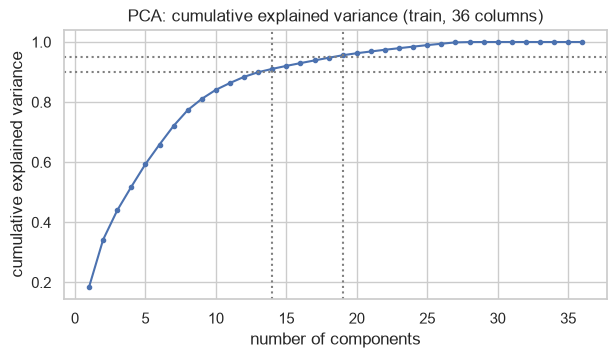

In [18]:
# ขั้น 8.1 — PCA (feature extraction): สร้างแกนใหม่ (PC) ที่เป็นผลรวมเชิงเส้นของ feature เดิม เรียงตาม variance ที่อธิบายได้
# ต่างจากขั้น 7: PCA "สร้าง" feature ใหม่ ไม่ได้ "เลือก" feature เดิม และไม่ได้ดู y เลย
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

# ต้อง standardize ก่อน PCA ไม่อย่างนั้นตัวแปรสเกลใหญ่ (เช่น visibility) จะครอบงำทุก PC
pre_cy = make_preprocessor("cyclic").fit(X_train)
Xt_cy = pd.DataFrame(pre_cy.transform(X_train), columns=pre_cy.get_feature_names_out())
pca_full = PCA(random_state=config.RANDOM_STATE).fit(Xt_cy)
cum = np.cumsum(pca_full.explained_variance_ratio_)            # variance สะสม
n90, n95 = int(np.searchsorted(cum, 0.90) + 1), int(np.searchsorted(cum, 0.95) + 1)   # ต้องใช้กี่ PC ถึง 90% / 95%
print(f"จำนวนคอลัมน์ก่อน PCA: {Xt_cy.shape[1]}")
print("สัดส่วน variance ที่อธิบายได้ PC1–PC5:", pca_full.explained_variance_ratio_[:5].round(3).tolist())
print(f"ต้องใช้ {n90} components เพื่อให้ได้ ≥ 90% และ {n95} components เพื่อให้ได้ ≥ 95%")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
for level, n in [(0.90, n90), (0.95, n95)]:
    ax.axhline(level, color="gray", ls=":")
    ax.axvline(n, color="gray", ls=":")
ax.set(title="PCA: cumulative explained variance (train, 36 columns)", xlabel="number of components", ylabel="cumulative explained variance")
savefig("08_pca_variance.png")
plt.show()

**ผลลัพธ์:**
- PC1–PC5 อธิบาย variance ได้ 18.5%, 15.8%, 9.7%, 7.9%, 7.5% — ไม่มี PC ไหนเด่นมาก
- ต้องใช้ **14 PC** จึงได้ ≥ 90% และ **19 PC** จึงได้ ≥ 95% (จาก 36 คอลัมน์) → ข้อมูลซ้ำซ้อนกันพอสมควรแต่บีบได้ไม่มาก

### 8.2 ตีความ PC แรกๆ (loading)
**โค้ดทำอะไร:** ดู 5 คอลัมน์ที่มีน้ำหนัก (loading) มากที่สุดของ PC1–PC3 — เครื่องหมายบอกทิศทาง, ขนาดบอกว่ามีส่วนมากแค่ไหน

In [19]:
# ขั้น 8.2 — ตีความ PC1–PC3 จาก loading (น้ำหนักของ feature เดิมในแต่ละ PC): ขนาดบอกว่ามีส่วนมากแค่ไหน เครื่องหมายบอกทิศทาง
loadings = pd.DataFrame(pca_full.components_[:3].T, index=Xt_cy.columns, columns=["PC1", "PC2", "PC3"])
for pc in loadings:
    top5 = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index)[:5].round(2)
    print(f"{pc}: {top5.to_dict()}")

PC1: {'humidity_pct': 0.53, 'dew_point_c': 0.39, 'visibility_10m': -0.32, 'is_raining': 0.31, 'wind_speed_ms': -0.29}
PC2: {'temp_c': 0.56, 'dew_point_c': 0.45, 'solar_radiation_mj': 0.44, 'hour_cos': -0.3, 'hour_sin': -0.21}
PC3: {'rainfall_mm': 0.51, 'is_raining': 0.49, 'hour_cos': -0.36, 'wind_speed_ms': 0.29, 'visibility_10m': -0.28}


**ผลลัพธ์:**
| PC | feature หลัก | ตีความ |
|---|---|---|
| PC1 | `humidity_pct` +0.53, `dew_point_c` +0.39, `visibility_10m` −0.32, `is_raining` +0.31, `wind_speed_ms` −0.29 | **"ความชื้น / อากาศมัว"** — ชื้นมาก, ฝนตก, มองเห็นไม่ไกล |
| PC2 | `temp_c` +0.56, `dew_point_c` +0.45, `solar_radiation_mj` +0.44, `hour_cos` −0.30 | **"ความอุ่น / กลางวัน"** — ร้อน แดดแรง (hour_cos ติดลบ = ช่วงกลางวัน) |
| PC3 | `rainfall_mm` +0.51, `is_raining` +0.49, `hour_cos` −0.36 | **"ฝน"** |

→ PC ที่ได้สอดคล้องกับกลุ่มตัวแปรที่สัมพันธ์กันใน correlation ของ `01_eda` 4.9 (temp–dew, humidity–visibility)

### 8.3 เทียบ CV: มี PCA vs ไม่มี PCA
**โค้ดทำอะไร:** ใส่ `PCA(n_components)` ในช่อง `select` ของ Pipeline (fit ใหม่ทุก fold) แล้วเทียบ MAE กับ Pipeline ที่ไม่มี PCA · ลองกับ Linear Regression และ kNN (tree-based ไม่ได้ประโยชน์จาก PCA เพราะ PC ผสมหลาย feature จนตัดแบ่งทีละ feature ได้ยากขึ้น)
- ใช้ `hour="cyclic"` ทั้งสองโมเดลเพื่อให้เริ่มจาก 36 คอลัมน์ชุดเดียวกับ 8.1

In [20]:
# ขั้น 8.3 — PCA ช่วยโมเดลไหม: ใส่ PCA ในช่อง select ของ Pipeline (fit ใหม่ทุก fold) แล้วเทียบ CV MAE กับไม่ใส่
# ลองกับ Linear และ kNN — tree-based ไม่ได้ประโยชน์เพราะ PC ผสมหลาย feature จนตัดแบ่งทีละ feature ยากขึ้น
N_PCA = [5, 10, 15, 20, 25]
pca_rows = []
for name, model, hour in [("Linear", LinearRegression(), "cyclic"), ("kNN (k=10)", KNeighborsRegressor(n_neighbors=10), "cyclic")]:
    no = cv_report(make_pipeline(model, hour=hour), name)
    gs = grid(make_pipeline(model, select=PCA(random_state=config.RANDOM_STATE), hour=hour), {"select__n_components": N_PCA})
    row = {"model": name, "ไม่มี PCA": no["MAE"]}
    row.update({f"PCA {n}": m for n, m in zip(N_PCA, -gs.cv_results_["mean_test_score"])})
    pca_rows.append(row)
pca_table = pd.DataFrame(pca_rows).set_index("model").round(1)
print("CV MAE (คัน/ชม.) — hour แบบ cyclic (36 คอลัมน์ก่อน PCA)")
print(pca_table)

CV MAE (คัน/ชม.) — hour แบบ cyclic (36 คอลัมน์ก่อน PCA)
            ไม่มี PCA  PCA 5  PCA 10  PCA 15  PCA 20  PCA 25
model                                                       
Linear          314.6  364.9   340.2   325.6   329.2   315.6
kNN (k=10)      194.4  200.8   190.5   189.5   201.3   195.0


**ผลลัพธ์:**
- **Linear Regression:** ไม่มี PCA = 314.6 · PCA ทุกจำนวนแย่กว่าหรือเท่ากัน (5 PC = 364.9, 25 PC = 315.6) → PCA ตัดข้อมูลบางส่วนทิ้ง และโมเดลเชิงเส้นบนข้อมูลที่หมุนแกนแล้วก็ยังเป็นเชิงเส้นเหมือนเดิม จึงไม่ได้อะไรเพิ่ม
- **kNN (k=10):** ไม่มี PCA = 194.4 · **PCA 15 PC = 189.5**, 10 PC = 190.5 → ดีขึ้นเล็กน้อย (~5 คัน, น้อยกว่า std ของ kNN ที่ ~8.6 ในขั้น 10) · kNN ใช้ระยะทาง การตัดมิติที่เป็น noise ออกทำให้ "เพื่อนบ้าน" มีความหมายขึ้น

**ตัดสินใจ:** ไม่ใช้ PCA กับ Linear Regression · สำหรับ kNN ให้ `PCA(15)` เป็นตัวเลือกหนึ่งใน tuning ขั้น 11 แล้วให้ CV ตัดสิน

---
## ขั้น 9 — Baseline (เพดานล่างที่ทุกโมเดลต้องชนะ)

**โค้ดทำอะไร:** วัด 3 baseline ด้วย `cv_report` (GroupKFold ชุดเดียวกับโมเดลจริง)
| baseline | ทายอย่างไร | บอกอะไร |
|---|---|---|
| `DummyRegressor(mean)` | ค่าเฉลี่ยของ training fold ทุกชั่วโมง | ถ้าไม่รู้อะไรเลย จะคลาดเท่าไร |
| `DummyRegressor(median)` | มัธยฐานของ training fold (ค่าคงที่ที่ทำให้ MAE ต่ำสุด) | เหมือนข้างบนแต่เหมาะกับ MAE กว่า |
| **เวลาอย่างเดียว** (`HourDayTypeMean`) | ค่าเฉลี่ยของ training fold แยกตาม **ชั่วโมง × (วันทำงาน / วันหยุด)** — 48 กลุ่ม | ถ้าใช้แค่ "ปฏิทิน" ไม่ใช้อากาศเลย จะได้แค่ไหน → โมเดลจริงต้องชนะตัวนี้ชัดเจน จึงพิสูจน์ได้ว่าข้อมูลอากาศมีประโยชน์ |

`HourDayTypeMean` เขียนเป็น estimator ของ sklearn (`fit` / `predict`) → ค่าเฉลี่ยถูกเรียนจาก training fold เท่านั้นเหมือนโมเดลอื่น · "วันหยุด" = เสาร์–อาทิตย์ หรือวันหยุดนักขัตฤกษ์ (`01_eda` 4.5: สองแบบนี้มีรูปร่างรายชั่วโมงเหมือนกัน)

In [21]:
# ขั้น 9 — Baseline: วัดว่าการทายแบบง่ายที่สุดคลาดเท่าไร เพื่อเป็นเกณฑ์ขั้นต่ำที่โมเดลจริงต้องชนะ
# ใช้ cv_report (GroupKFold ชุดเดียวกับโมเดลจริง) → เทียบกันได้ตรงๆ
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor


# เขียนเป็น estimator ของ sklearn (fit/predict) → ค่าเฉลี่ยถูกเรียนจาก training fold เท่านั้นเหมือนโมเดลอื่น
class HourDayTypeMean(BaseEstimator, RegressorMixin):
    """baseline จากเวลาอย่างเดียว: ทาย = ค่าเฉลี่ยยอดเช่าของ (ชั่วโมง, วันทำงาน/วันหยุด) ที่เรียนจากข้อมูล fit เท่านั้น"""

    def fit(self, X, y):
        key = self._key(X)
        self.table_ = pd.Series(np.asarray(y), index=key).groupby(level=[0, 1]).mean()   # 24 ชั่วโมง × 2 ประเภทวัน = 48 ค่า
        self.global_mean_ = float(np.mean(y))
        return self

    def predict(self, X):
        idx = pd.MultiIndex.from_arrays(self._key(X))
        return self.table_.reindex(idx).fillna(self.global_mean_).to_numpy()   # กลุ่มที่ไม่เคยเห็น → ใช้ค่าเฉลี่ยรวม

    @staticmethod
    def _key(X):
        # วันหยุด = เสาร์–อาทิตย์ หรือวันหยุดนักขัตฤกษ์ (รูปแบบรายชั่วโมงเหมือนกันใน 01_eda 4.5)
        off_day = ((X["is_weekend"] == 1) | (X["is_holiday"] == 1)).astype(int).to_numpy()
        return [X["hour"].to_numpy(), off_day]


baseline_rows = [
    cv_report(DummyRegressor(strategy="mean"), "Dummy (mean)"),       # ทายค่าเฉลี่ยทุกชั่วโมง
    cv_report(DummyRegressor(strategy="median"), "Dummy (median)"),   # ทายมัธยฐาน (ค่าคงที่ที่ทำให้ MAE ต่ำสุด)
    cv_report(HourDayTypeMean(), "เวลาอย่างเดียว (hour × วันทำงาน/วันหยุด)"),
]
baselines = pd.DataFrame(baseline_rows).set_index("model").round(3)
baselines[["MAE", "MAE_std", "MSE", "RMSE", "R2", "MAE_train"]].round({"MAE": 1, "MAE_std": 1, "MSE": 0, "RMSE": 1, "R2": 3, "MAE_train": 1})

,MAE,MAE_std,MSE,RMSE,R2,MAE_train
model,,,,,,
Dummy (mean),527.5,12.9,423381.0,650.4,-0.003,527.1
Dummy (median),512.2,16.6,454336.0,673.6,-0.075,511.8
เวลาอย่างเดียว (hour × วันทำงาน/วันหยุด),401.0,10.5,270794.0,520.2,0.358,396.0


**ผลลัพธ์:**
- `Dummy (mean)` MAE = **527.5** · R² ≈ 0 (นิยามของ R² คือเทียบกับการทายค่าเฉลี่ย)
- `Dummy (median)` MAE = **512.2** ต่ำกว่า mean ตามทฤษฎี แต่ RMSE / MSE สูงกว่า (673.6 vs 650.4 · MSE 454,336 vs 423,381) และ R² ติดลบ — เพราะ median ทำให้ MAE ต่ำสุด ส่วน mean ทำให้ RMSE ต่ำสุด
- **เวลาอย่างเดียว** MAE = **401.0** · R² = 0.358 → รู้แค่ชั่วโมงกับประเภทวันก็ลดความคลาดเคลื่อนจาก ~512 เหลือ ~401 คัน (ราว 22%)

**ตัดสินใจ:** โมเดลในขั้น 10 ต้องได้ MAE **ต่ำกว่า 401** อย่างชัดเจนจึงถือว่าข้อมูลอากาศช่วยจริง

---
## ขั้น 10 — เทียบ 4 โมเดลด้วย GroupKFold

**โค้ดทำอะไร:** วัด 4 โมเดลจาก 4 ตระกูลด้วยค่า default (ยังไม่ tune) ผ่าน `cv_report` · ทุกตัวใช้ทุก feature (ตามขั้น 7) และเลือก `hour=` ตามตารางในขั้น 5.4
| # | โมเดล | ตระกูล | `hour=` |
|---|---|---|---|
| 1 | `LinearRegression` | เส้นตรง | `"onehot"` |
| 2 | `KNeighborsRegressor(n_neighbors=10)` | ระยะทาง | `"cyclic"` |
| 3 | `RandomForestRegressor(n_estimators=200)` | ต้นไม้หลายต้นแบบ bagging (เฉลี่ยต้นไม้อิสระ) | `"raw"` |
| 4 | `HistGradientBoostingRegressor` | ต้นไม้หลายต้นแบบ boosting (ต้นใหม่แก้ error ต้นก่อน) | `"raw"` |

`gap (CV − train)` = MAE บน validation ลบ MAE บน training fold → ยิ่งมาก = ยิ่ง overfit

In [22]:
# ขั้น 10 — เทียบ 4 โมเดลจาก 4 ตระกูลด้วยค่า default (ยังไม่ tune) ผ่าน GroupKFold ชุดเดียวกัน
# แต่ละตัวใช้ encoding ชั่วโมงที่เหมาะกับตัวเอง: เส้นตรง → onehot, ระยะทาง → cyclic, ต้นไม้ → raw
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

MODELS = {
    "Linear Regression": (LinearRegression(), "onehot"),                       # เส้นตรง: เร็ว อ่าน coefficient ได้
    "kNN": (KNeighborsRegressor(n_neighbors=10), "cyclic"),                   # ระยะทาง: ไม่สมมติรูปร่างความสัมพันธ์
    "Random Forest": (RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=config.RANDOM_STATE), "raw"),   # bagging
    "HistGradientBoosting": (HistGradientBoostingRegressor(random_state=config.RANDOM_STATE), "raw"),               # boosting
}
compare = pd.DataFrame([cv_report(make_pipeline(m, hour=h), name) for name, (m, h) in MODELS.items()]).set_index("model")
# gap = MAE บน validation − MAE บน train: gap ใหญ่ = overfit (จำ train) · gap เล็กแต่ MAE สูง = underfit
compare["gap (CV − train)"] = compare["MAE"] - compare["MAE_train"]
compare[["MAE", "MAE_std", "MSE", "RMSE", "R2", "MAE_train", "gap (CV − train)", "fit_s"]].round(
    {"MAE": 1, "MAE_std": 1, "MSE": 0, "RMSE": 1, "R2": 3, "MAE_train": 1, "gap (CV − train)": 1, "fit_s": 2})

,MAE,MAE_std,MSE,RMSE,R2,MAE_train,gap (CV − train),fit_s
model,,,,,,,,
Linear Regression,266.2,4.8,120964.0,347.7,0.713,259.8,6.4,0.05
kNN,194.4,8.6,84316.0,289.9,0.800,151.9,42.5,0.02
Random Forest,122.4,9.4,40192.0,199.4,0.904,36.8,85.6,5.25
HistGradientBoosting,114.1,10.0,34462.0,184.6,0.918,69.0,45.1,0.31


**ผลลัพธ์:**
| โมเดล | CV MAE | MSE | RMSE | R² | gap | อ่านว่า |
|---|---|---|---|---|---|---|
| Linear Regression | 266.2 ± 4.8 | 120,964 | 347.7 | 0.713 | 6.4 | ชนะ baseline เวลาอย่างเดียว (401) ชัด แต่จับความสัมพันธ์โค้ง (อุณหภูมิ, ฝน) และ interaction ชั่วโมง × วันไม่ได้ · gap เล็ก = **underfit** มากกว่า overfit |
| kNN | 194.4 ± 8.6 | 84,316 | 289.9 | 0.800 | 42.5 | ดีกว่าเส้นตรงมาก เพราะไม่สมมติรูปร่างความสัมพันธ์ |
| Random Forest | 122.4 ± 9.4 | 40,192 | 199.4 | 0.904 | **85.6** | แม่นอันดับ 2 แต่ MAE บน train แค่ 36.8 → **overfit มากที่สุด** (ต้นไม้ลึกจำข้อมูล train) |
| **HistGradientBoosting** | **114.1 ± 10.0** | **34,462** | **184.6** | **0.918** | 45.1 | **ดีที่สุด** และ fit เร็วกว่า RF เกิน 10 เท่า (คอลัมน์ `fit_s` — ตัวเลขเวลาเปลี่ยนทุกครั้งที่รัน) |

- MSE / RMSE / R² จัดลำดับเหมือน MAE ทุกตัว · MSE ใน CV ไม่เท่ากับ RMSE² พอดี เพราะเป็นค่าเฉลี่ยของ MSE แต่ละ fold (เช่น HGB: 184.6² ≈ 34,077 vs 34,462)
- ทุกโมเดลชนะ baseline "เวลาอย่างเดียว" (401.0) → **ข้อมูลอากาศมีประโยชน์จริง** · HGB ลดความคลาดเคลื่อนจาก baseline ได้ ~72%
- ลำดับ เส้นตรง → ระยะทาง → ต้นไม้ ตรงกับที่คาดไว้ใน `01_eda` 4.5 / 4.7 (ความสัมพันธ์โค้ง + interaction เป็นจุดที่ tree-based ได้เปรียบ)
- ความต่างระหว่าง HGB กับ RF (8.3 คัน) น้อยกว่า std ของทั้งคู่ (~10) → ต้องดูหลัง tuning อีกครั้ง

**โค้ดทำอะไร:** วาดกราฟแท่ง MAE ± std ของ baseline (สีเทา) และ 4 โมเดล (สีน้ำเงิน)

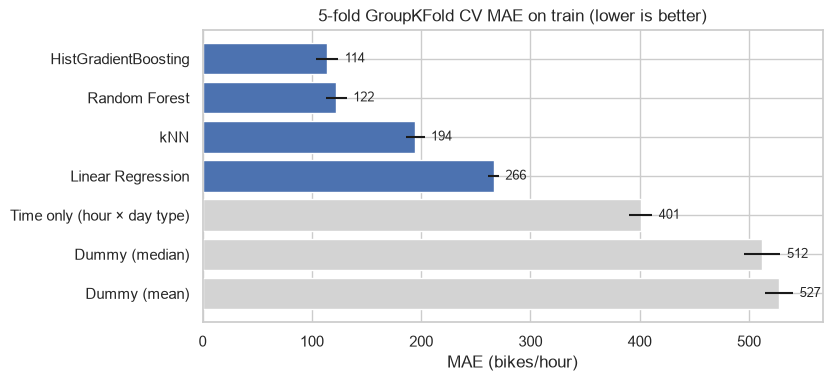

In [23]:
# ขั้น 10 (ต่อ) — กราฟ MAE ± std ของ baseline (เทา) เทียบกับ 4 โมเดล (น้ำเงิน) → เห็นว่าทุกโมเดลชนะ baseline แค่ไหน
plot_df = pd.concat([baselines[["MAE", "MAE_std"]], compare[["MAE", "MAE_std"]]]).sort_values("MAE", ascending=False)
plot_df = plot_df.rename(index={"เวลาอย่างเดียว (hour × วันทำงาน/วันหยุด)": "Time only (hour × day type)"})   # ฟอนต์กราฟไม่มีภาษาไทย
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(plot_df.index, plot_df["MAE"], xerr=plot_df["MAE_std"],
        color=["C0" if n in compare.index else "lightgray" for n in plot_df.index])   # เทา = baseline
for i, (v, sd) in enumerate(zip(plot_df["MAE"], plot_df["MAE_std"])):
    ax.text(v + sd + 6, i, f"{v:.0f}", va="center", fontsize=9)
ax.set(title="5-fold GroupKFold CV MAE on train (lower is better)", xlabel="MAE (bikes/hour)")
savefig("10_model_comparison.png")
plt.show()

**ผลลัพธ์:** กราฟเห็นลำดับชัดเจน — baseline 3 ตัว (401–528) ห่างจากโมเดลจริงมาก และ error bar ของ RF กับ HGB ซ้อนกัน (ยังแยกไม่ขาดจนกว่าจะ tune)

---
## ขั้น 11 — Hyperparameter tuning

**โค้ดทำอะไร:** tune ทีละโมเดลด้วย `cv` + `groups=groups_train` + `scoring="neg_mean_absolute_error"` (test ยังปิดอยู่)
| โมเดล | วิธีค้น | สิ่งที่ลอง |
|---|---|---|
| Linear Regression | – (ไม่มีไฮเปอร์พารามิเตอร์) | ฝึกบน y ดิบ vs **`log1p(y)`** |
| kNN | `GridSearchCV` (28 ชุด) | `n_neighbors` 3–30, `weights` uniform/distance, มี/ไม่มี `PCA(15)` (ขั้น 8) · และแบบ `log1p(y)` |
| Random Forest | `RandomizedSearchCV` (สุ่ม 15 จาก 64 ชุด) | `n_estimators`, `min_samples_leaf`, `max_features`, `max_depth` |
| HistGradientBoosting | `RandomizedSearchCV` (สุ่ม 30 จาก 480 ชุด) | `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` · และลอง `log1p(y)` กับพารามิเตอร์ที่ดีที่สุด |

**`log1p(y)` ทำงานอย่างไร:** `TransformedTargetRegressor` ฝึกโมเดลบน $\log(1 + y)$ แล้วแปลงค่าทำนายกลับด้วย $e^{\hat{z}} - 1$ ก่อนคิดคะแนน → **MAE ยังเป็นหน่วยคัน/ชม.** และการแปลงอยู่ใน Pipeline จึง fit ใหม่ทุก fold

⏱️ cell นี้ใช้เวลาหลายนาที (RF และ HGB ต้อง fit หลายร้อยครั้ง)

In [24]:
# ขั้น 11 — Hyperparameter tuning ทีละโมเดลด้วย CV บน train (GroupKFold + groups, เลือกด้วย MAE) · test ยังปิดอยู่
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RandomizedSearchCV


def log_target(pipe):
    """ฝึกบน log1p(y) แล้วแปลงค่าทำนายกลับด้วย expm1 → MAE ยังวัดเป็นคัน/ชม."""
    # y เบ้ขวาและผลของอากาศเป็นแบบ "คูณ" → บนสเกล log กลายเป็น "บวก" ซึ่งโมเดลเชิงเส้นจับได้
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)


def rsearch(pipe, dist, n_iter):
    # RandomizedSearchCV: สุ่มลอง n_iter ชุดจาก grid ใหญ่ — ถูกกว่าลองทุกชุด (GridSearch) มากเมื่อพารามิเตอร์เยอะ
    rs = RandomizedSearchCV(pipe, dist, n_iter=n_iter, cv=cv, scoring="neg_mean_absolute_error",
                            n_jobs=-1, random_state=config.RANDOM_STATE)
    return rs.fit(X_train, y_train, groups=groups_train)


searches = {}
t0 = time.time()
# Linear: ไม่มีไฮเปอร์พารามิเตอร์ → ลองแค่ "แปลง y ด้วย log1p หรือไม่"
searches["Linear Regression"] = grid(make_pipeline(LinearRegression(), hour="onehot"), {"model__fit_intercept": [True]})
searches["Linear Regression + log1p(y)"] = grid(log_target(make_pipeline(LinearRegression(), hour="onehot")),
                                                 {"regressor__model__fit_intercept": [True]})
# kNN: จำนวนเพื่อนบ้าน, การถ่วงน้ำหนัก, PCA (ขั้น 8), log1p(y)
searches["kNN"] = grid(make_pipeline(KNeighborsRegressor(), hour="cyclic"), {
    "model__n_neighbors": [3, 5, 7, 10, 15, 20, 30],
    "model__weights": ["uniform", "distance"],       # distance = เพื่อนบ้านที่ใกล้กว่ามีน้ำหนักมากกว่า
    "select": ["passthrough", PCA(n_components=15, random_state=config.RANDOM_STATE)],
})
searches["kNN + log1p(y)"] = grid(log_target(make_pipeline(KNeighborsRegressor(), hour="cyclic")), {
    "regressor__model__n_neighbors": [5, 10, 15, 20, 30],
    "regressor__model__weights": ["uniform", "distance"],
})
# Random Forest — min_samples_leaf / max_depth คุมความลึกของต้นไม้ (ลด overfit) · max_features สุ่ม feature ต่อการแบ่ง
searches["Random Forest"] = rsearch(
    make_pipeline(RandomForestRegressor(n_jobs=1, random_state=config.RANDOM_STATE), hour="raw"), {
        "model__n_estimators": [200, 300],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": [0.33, 0.5, 0.75, 1.0],
        "model__max_depth": [None, 20],
    }, n_iter=15)
# HistGradientBoosting — learning_rate ต่ำ + max_iter มาก = เรียนช้าแต่ละเอียด · max_leaf_nodes = ขนาดต้นไม้ · l2 = regularization
searches["HistGradientBoosting"] = rsearch(
    make_pipeline(HistGradientBoostingRegressor(random_state=config.RANDOM_STATE), hour="raw"), {
        "model__learning_rate": [0.02, 0.03, 0.05, 0.1, 0.2],
        "model__max_iter": [200, 400, 800],
        "model__max_leaf_nodes": [15, 31, 63, 127],
        "model__min_samples_leaf": [5, 10, 20, 40],
        "model__l2_regularization": [0.0, 1.0],
    }, n_iter=30)
# tree + log1p(y): ใช้พารามิเตอร์ที่ดีที่สุดของ HGB แล้วเปลี่ยนแค่การแปลง y
from sklearn.base import clone
hgb_log = cv_report(log_target(clone(searches["HistGradientBoosting"].best_estimator_)), "HistGradientBoosting + log1p(y)")
print(f"เวลาทั้งหมด {time.time() - t0:.0f} วินาที")

# สรุปผล tuning: CV MAE ของพารามิเตอร์ที่ดีที่สุด เทียบกับค่า default จากขั้น 10
tuned = pd.DataFrame([{
    "model": name,
    "CV MAE": -s.best_score_,
    "MAE_std": s.cv_results_["std_test_score"][s.best_index_],
    "best params": {k.split("__")[-1]: (type(v).__name__ if hasattr(v, "fit") else v) for k, v in s.best_params_.items()
                    if not k.endswith("fit_intercept")},
} for name, s in searches.items()]).set_index("model")
tuned["ก่อน tune"] = [compare["MAE"].get(n.replace(" + log1p(y)", ""), np.nan) if "log1p" not in n else np.nan for n in tuned.index]
tuned.loc["HistGradientBoosting + log1p(y)"] = [hgb_log["MAE"], hgb_log["MAE_std"], "(พารามิเตอร์เดียวกับ HGB)", np.nan]
print(tuned.round(1).to_string())

เวลาทั้งหมด 74 วินาที
                                 CV MAE  MAE_std                                                                                                       best params  ก่อน tune
model                                                                                                                                                                        
Linear Regression                 266.2      4.8                                                                                                                {}      266.2
Linear Regression + log1p(y)      211.0      6.9                                                                                                                {}        NaN
kNN                               183.7      7.8                                                        {'n_neighbors': 5, 'weights': 'distance', 'select': 'PCA'}      194.4
kNN + log1p(y)                    188.7      9.3                                                            

**ผลลัพธ์:**
| โมเดล | ก่อน tune | หลัง tune | พารามิเตอร์ที่ได้ |
|---|---|---|---|
| Linear Regression | 266.2 | 266.2 | – |
| **Linear Regression + log1p(y)** | – | **211.0 ± 6.9** | ดีขึ้น **55 คัน (−21%)** |
| kNN | 194.4 | **183.7 ± 7.8** | k = 5, `weights="distance"`, **มี PCA(15)** |
| kNN + log1p(y) | – | 188.7 ± 9.3 | k = 15, distance → แย่กว่าไม่แปลง |
| Random Forest | 122.4 | **121.8 ± 9.1** | 200 ต้น, `min_samples_leaf=1`, `max_features=0.75` → ดีขึ้นแค่ 0.6 |
| **HistGradientBoosting** | 114.1 | **109.0 ± 8.1** | `learning_rate=0.02`, `max_iter=400`, `max_leaf_nodes=127`, `min_samples_leaf=5`, `l2=1.0` |
| HistGradientBoosting + log1p(y) | – | 110.7 ± 8.0 | แย่กว่าไม่แปลงเล็กน้อย |

**อ่านผล:**
- **log1p ช่วยโมเดลเชิงเส้นมาก** — ผลของอากาศต่อยอดเช่าเป็นแบบ "คูณ" (ฝนตก → ยอดลด ~80% ไม่ว่ายอดปกติจะเป็นหลักร้อยหรือหลักพัน, `01_eda` 4.8) · บนสเกล log ผลแบบคูณกลายเป็นแบบ "บวก" ซึ่งโมเดลเชิงเส้นจับได้พอดี
- log1p **ไม่ช่วย** kNN และ HGB — สองโมเดลนี้ไม่ได้สมมติรูปร่างความสัมพันธ์อยู่แล้ว และ log บีบค่าช่วงหางขวา (ชั่วโมงพีค) ทำให้ error ของช่วงนั้นถูกให้น้ำหนักน้อยลงตอนฝึก
- kNN เลือก PCA(15) จริงตามที่เห็นในขั้น 8 · RF เกือบไม่ได้อะไรจากการ tune (ค่า default ดีอยู่แล้ว)
- HGB ดีขึ้น ~5 คัน: `learning_rate` ต่ำ + ต้นไม้ใหญ่ขึ้น (`max_leaf_nodes=127`) · ⚠️ ค่าที่ได้อยู่ที่ขอบของ grid (`learning_rate` ต่ำสุด, `max_leaf_nodes`/`min_samples_leaf` ค่าสุดขอบ) อาจลองขยาย grid ได้อีก แต่ความต่างที่เหลือน่าจะเล็กกว่า std (~8)

---
## ขั้น 12 — เลือกโมเดล + ตาราง CLO4

**โค้ดทำอะไร:** เอาตัวที่ดีที่สุดของแต่ละตระกูลจากขั้น 11 (Linear ใช้แบบ log1p) มาวัดทรัพยากรที่ใช้
- **CV MAE ± std** จากขั้น 11 (เกณฑ์หลักในการเลือก — **ไม่ได้ดู test**)
- **fit ทั้ง train** = เวลาฝึกใหม่บน train ทั้ง 6,768 แถว 1 ครั้ง
- **latency / 1 แถว** = มัธยฐานของเวลาทำนาย 1 แถว 30 ครั้ง (แบบที่แอปจะใช้จริง)

⚠️ เวลา (fit, latency) เปลี่ยนเล็กน้อยทุกครั้งที่รันและขึ้นกับเครื่อง ใช้ดู "ลำดับขนาด" ไม่ใช่ค่าแน่นอน

In [25]:
# ขั้น 12 — เลือกโมเดลสุดท้าย: เทียบตัวที่ดีที่สุดของแต่ละตระกูลทั้งความแม่น (CV MAE, เกณฑ์หลัก) และทรัพยากร (ตาราง CLO4)
FINALISTS = {   # ตัวที่ดีที่สุดของแต่ละตระกูลจากขั้น 11 (best_estimator_ ถูก refit บน train ทั้งหมดแล้ว)
    "Linear Regression + log1p(y)": searches["Linear Regression + log1p(y)"],
    "kNN": searches["kNN"],
    "Random Forest": searches["Random Forest"],
    "HistGradientBoosting": searches["HistGradientBoosting"],
}
one_row = X_train.iloc[[0]]          # ทำนายทีละ 1 แถว แบบที่แอปใช้งานจริง
rows = []
for name, s in FINALISTS.items():
    est = s.best_estimator_
    t0 = time.perf_counter()
    clone(est).fit(X_train, y_train)          # clone = สำเนาที่ยังไม่ fit → วัดเวลาฝึกใหม่โดยไม่ทับโมเดลเดิม
    fit_s = time.perf_counter() - t0
    lat = []
    for _ in range(30):
        t0 = time.perf_counter()
        est.predict(one_row)
        lat.append(time.perf_counter() - t0)
    rows.append({
        "model": name,
        "CV MAE": -s.best_score_, "± std": s.cv_results_["std_test_score"][s.best_index_],
        "fit ทั้ง train (s)": fit_s, "latency / 1 แถว (ms)": 1000 * np.median(lat),   # มัธยฐาน 30 ครั้ง ลดผลของรอบที่สะดุด
    })
clo4 = pd.DataFrame(rows).set_index("model").sort_values("CV MAE")   # เรียงตาม CV MAE → แถวแรกคือตัวที่เลือก
clo4.round({"CV MAE": 1, "± std": 1, "fit ทั้ง train (s)": 2, "latency / 1 แถว (ms)": 1})

,CV MAE,± std,fit ทั้ง train (s),latency / 1 แถว (ms)
model,,,,
HistGradientBoosting,109.0,8.1,4.16,10.6
Random Forest,121.8,9.1,3.38,11.1
kNN,183.7,7.8,0.02,2.7
Linear Regression + log1p(y),211.0,6.9,0.02,2.7


**ผลลัพธ์:**
| โมเดล | CV MAE | ข้อสังเกต |
|---|---|---|
| **HistGradientBoosting** | **109.0 ± 8.1** | แม่นที่สุด · fit นานกว่า Linear/kNN (หลายวินาที vs เสี้ยววินาที เพราะ `learning_rate` ต่ำ + 400 รอบ) · ทำนาย 1 แถวใช้ไม่กี่มิลลิวินาที เร็วพอสำหรับแอป |
| Random Forest | 121.8 ± 9.1 | แม่นอันดับ 2 · เวลา fit และ latency อยู่ระดับเดียวกับ HGB (ไม่กี่วินาที / ไม่กี่มิลลิวินาที) |
| kNN | 183.7 ± 7.8 | fit แทบไม่ใช้เวลาเพราะแค่เก็บข้อมูล train ไว้ แต่ตอนทำนายต้องหาเพื่อนบ้านจากข้อมูลทั้งหมด |
| Linear + log1p(y) | 211.0 ± 6.9 | เร็วที่สุด อ่าน coefficient ได้ แต่คลาดมากกว่า HGB ~2 เท่า |

**ตัดสินใจ: เลือก HistGradientBoosting**
- MAE ต่ำที่สุด (ต่างจาก RF 12.8 คัน ≈ 1.5 เท่าของ std จึงไม่ถือว่าเสมอกัน)
- ทรัพยากรไม่ใช่ตัวตัดสิน: ทุกตัว fit ใช้ไม่เกินไม่กี่วินาทีและทำนาย 1 แถวในระดับมิลลิวินาที → ใช้งานจริงได้ทั้งหมด
- RF ตกไปเพราะแม่นน้อยกว่า

**โค้ดทำอะไร:** ตั้ง `final_model` = Pipeline ที่เลือก (`best_estimator_` ของ `RandomizedSearchCV` ซึ่งถูก **refit บน train ทั้งหมด** ด้วยพารามิเตอร์ที่ดีที่สุดแล้ว) เพื่อใช้ต่อในขั้น 13
- Pipeline นี้รวม preprocess (imputer, scaler, one-hot) ไว้ในตัว → input คือ `X` 17 คอลัมน์แบบเดียวกับ `X_train` (หลัง `add_features`)
- ไม่บันทึกเป็นไฟล์ — ขั้น 13 ใช้ `final_model` ในหน่วยความจำโดยตรง (รัน notebook นี้ใหม่ได้โมเดลเดิมทุกครั้งเพราะตั้ง `random_state` ไว้)

In [26]:
# ขั้น 12 (ต่อ) — ตั้ง final_model = Pipeline ที่ CV MAE ต่ำสุด (เลือกจาก CV เท่านั้น ยังไม่ได้ดู test)
best_name = clo4.index[0]
final_model = FINALISTS[best_name].best_estimator_      # รวม preprocess + model ไว้ในตัว → รับ X ดิบ 17 คอลัมน์ได้เลย
print(f"โมเดลที่เลือก: {best_name} | CV MAE = {clo4.loc[best_name, 'CV MAE']:.1f} คัน/ชม.")
print(getattr(final_model, "named_steps", {}).get("model", final_model))

โมเดลที่เลือก: HistGradientBoosting | CV MAE = 109.0 คัน/ชม.
HistGradientBoostingRegressor(l2_regularization=1.0, learning_rate=0.02,
                              max_iter=400, max_leaf_nodes=127,
                              min_samples_leaf=5, random_state=42)


**ผลลัพธ์:** `final_model` = HistGradientBoosting (CV MAE = 109.0 คัน/ชม.) พร้อมใช้ในขั้น 13

---
## ขั้น 13 — ประเมิน test ครั้งเดียว, error analysis, ทำนายข้อมูลใหม่

### 13.1 ประเมิน test (ครั้งเดียว)
**โค้ดทำอะไร:** ใช้ `final_model` (HGB ที่เลือกในขั้น 12 จาก CV เท่านั้น) ทำนาย `X_test` 1,697 แถว — **เป็นครั้งแรกและครั้งเดียวที่แตะ test** · ค่าทำนายติดลบ `clip` เป็น 0 เพราะจำนวนคันติดลบไม่ได้ (ใช้กติกาเดียวกันในแอป) แล้วคำนวณ MAE / MSE / RMSE / R² เทียบกับ CV

In [27]:
# ขั้น 13.1 — ประเมิน test "ครั้งเดียว": ครั้งแรกที่แตะ test และห้ามกลับไปแก้โมเดลหลังเห็นผล
# Pipeline แปลง X_test ด้วยค่าที่เรียนจาก train (median, mean/std) → ไม่มีข้อมูล test รั่วเข้าโมเดล
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

raw_pred = final_model.predict(X_test)
pred_test = np.clip(raw_pred, 0, None)          # จำนวนคันติดลบไม่ได้
test_scores = {
    "MAE": mean_absolute_error(y_test, pred_test),      # metric หลัก: คลาดเฉลี่ยกี่คัน/ชม.
    "MSE": mean_squared_error(y_test, pred_test),       # หน่วยเป็นคัน² → รายงานตามโจทย์ แต่อธิบายด้วย RMSE
    "RMSE": root_mean_squared_error(y_test, pred_test),
    "R2": r2_score(y_test, pred_test),                  # สัดส่วน variance ที่อธิบายได้
}
# เทียบกับ CV: ถ้าใกล้กัน = โมเดลไม่ overfit และ CV ประเมินได้สมจริง
cv_best = clo4.loc[best_name]
print(f"ค่าทำนายติดลบที่ถูก clip เป็น 0: {(raw_pred < 0).sum()} จาก {len(raw_pred):,} แถว")
print(pd.DataFrame({
    "CV บน train (5-fold)": [cv_best["CV MAE"], np.nan, np.nan, np.nan],
    "test (ครั้งเดียว)": [test_scores["MAE"], test_scores["MSE"], test_scores["RMSE"], test_scores["R2"]],
}, index=["MAE", "MSE", "RMSE", "R2"]).round(3))

ค่าทำนายติดลบที่ถูก clip เป็น 0: 3 จาก 1,697 แถว
      CV บน train (5-fold)  test (ครั้งเดียว)
MAE                109.028             97.427
MSE                    NaN          28947.710
RMSE                   NaN            170.140
R2                     NaN              0.919


**ผลลัพธ์:**
- ค่าทำนายติดลบมีแค่ **3 จาก 1,697 แถว** (clip เป็น 0)
- **test MAE = 97.4 คัน/ชม.** · MSE = 28,947.7 คัน² (= 170.1²) · RMSE = 170.1 · **R² = 0.919** — ใกล้เคียงกับ CV (MAE 109.0) → โมเดลไม่ได้ overfit กับ train และ CV ประเมินได้สมจริง
- test MAE **ต่ำกว่า** CV ~12 คัน ตรงกับที่คาดไว้ใน `01_eda` 3.2: test มีชั่วโมงฤดูหนาว 31.5% (train 22.9%) ซึ่งยอดต่ำ ค่าคลาดเป็นคันจึงเล็กตาม — ไม่ได้แปลว่าโมเดลเก่งขึ้น (ดู 13.2)
- RMSE ≈ 1.75 เท่าของ MAE → มีบางชั่วโมงที่ทายพลาดก้อนใหญ่ (ดู 13.4)

### 13.2 Error analysis แยกกลุ่ม
**โค้ดทำอะไร:** สร้างตาราง `res` (ค่าจริง, ค่าทำนาย, error = ทำนาย − จริง) แล้วสรุปตามฤดู / ประเภทวัน / ฝน
- `MAE / mean_y (%)` = ความคลาดเทียบกับระดับยอดปกติของกลุ่มนั้น (เทียบข้ามกลุ่มที่สเกลต่างกันได้)
- `bias` = ค่าเฉลี่ยของ error → บวก = ทายสูงเกินโดยเฉลี่ย

In [28]:
# ขั้น 13.2 — Error analysis แยกกลุ่ม: โมเดลพลาดตรงไหน (ฤดู / ประเภทวัน / ฝน)
res = test[["date", "hour", "seasons", "temp_c", "humidity_pct", "rainfall_mm", "is_weekend", "is_holiday"]].copy()
res["y"] = y_test.to_numpy()
res["pred"] = pred_test
res["error"] = res["pred"] - res["y"]          # บวก = ทายสูงเกิน
res["abs_error"] = res["error"].abs()
res["day_type"] = np.where((res["is_weekend"] == 1) | (res["is_holiday"] == 1), "วันหยุด", "วันทำงาน")


def group_err(col):
    # MAE / mean_y = ความคลาดเทียบกับระดับยอดของกลุ่ม → เทียบข้ามกลุ่มที่สเกลต่างกันได้ · bias = ทายสูง/ต่ำเกินโดยเฉลี่ย
    g = res.groupby(col).agg(n=("y", "size"), mean_y=("y", "mean"), MAE=("abs_error", "mean"), bias=("error", "mean"))
    g["MAE / mean_y (%)"] = 100 * g["MAE"] / g["mean_y"]
    return g.round(1)


print("แยกฤดู:")
print(group_err("seasons").sort_values("mean_y"))
print("\nแยกประเภทวัน:")
print(group_err("day_type"))
print("\nแยกฝน:")
print(group_err(np.where(res["rainfall_mm"] > 0, "ฝนตก", "ไม่มีฝน")))

แยกฤดู:
           n  mean_y    MAE  bias  MAE / mean_y (%)
seasons                                            
Winter   552   211.7   49.7   5.5              23.5
Spring   336   596.0   97.0  30.3              16.3
Autumn   425   805.5  126.4  49.7              15.7
Summer   384  1018.1  134.3  20.6              13.2

แยกประเภทวัน:
             n  mean_y    MAE  bias  MAE / mean_y (%)
day_type                                             
วันทำงาน  1128   681.3  102.6  18.6              15.1
วันหยุด    569   495.4   87.2  37.4              17.6

แยกฝน:
            n  mean_y    MAE  bias  MAE / mean_y (%)
ฝนตก      103   180.2  159.8  71.2              88.7
ไม่มีฝน  1594   647.3   93.4  21.9              14.4


**ผลลัพธ์:**
- **ฤดู:** MAE เป็นคันต่ำสุดในฤดูหนาว (49.7) สูงสุดในฤดูร้อน (134.3) — แต่เทียบกับระดับยอดแล้ว **ฤดูหนาวแย่ที่สุด (23.5%)** ส่วนฤดูร้อนดีที่สุด (13.2%) → ยืนยันว่า MAE รวมของ test ที่ดูดีมาจากสัดส่วนฤดูหนาว
- **ประเภทวัน:** วันทำงาน MAE 102.6 (15.1%) · วันหยุด 87.2 (17.6%) · bias วันหยุด +37.4 → วันหยุดทายสูงเกินบ่อยกว่า
- **ฝน:** ชั่วโมงที่ฝนตก (103 แถว) MAE = 159.8 ขณะที่ยอดเฉลี่ยแค่ 180.2 → **คลาด 88.7% ของยอด** และ bias +71.2 (ทายสูงเกิน) · ชั่วโมงไม่มีฝน 14.4% → **ฝนคือจุดอ่อนที่สุดของโมเดล** (ชั่วโมงฝนตกมีแค่ ~6% ของ train ให้เรียน)
- bias เป็นบวกทุกกลุ่ม → โดยรวมโมเดลทายสูงกว่าจริงเล็กน้อยใน test

### 13.3 กราฟค่าจริง vs ค่าทำนาย, residual, MAE รายชั่วโมง
**โค้ดทำอะไร:** (ซ้าย) scatter ค่าจริง vs ค่าทำนาย — จุดบนเส้นทแยง = ทายถูก · (กลาง) residual vs ค่าทำนาย — ควรกระจายรอบ 0 เท่าๆ กัน · (ขวา) MAE รายชั่วโมง (แท่ง) คู่กับยอดจริงเฉลี่ย (เส้น)

MAE สูงสุด 3 ชั่วโมง: {19: 175.0, 18: 173.0, 8: 168.0}
MAE ต่ำสุด 3 ชั่วโมง: {4: 24.0, 3: 27.0, 5: 31.0}


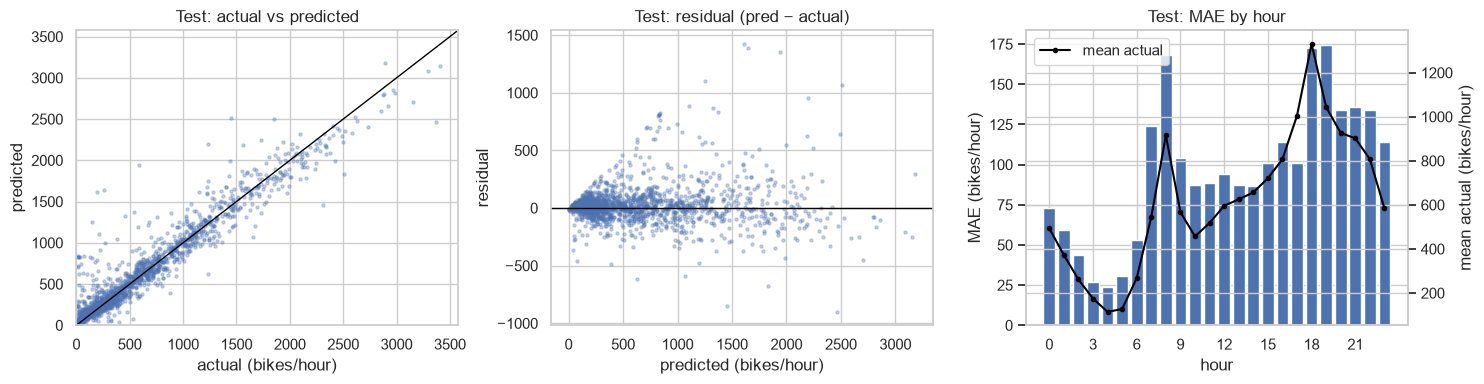

In [29]:
# ขั้น 13.3 — กราฟวินิจฉัย: (ซ้าย) ค่าจริง vs ค่าทำนาย (กลาง) residual (ขวา) MAE รายชั่วโมง
by_hour = res.groupby("hour")[["abs_error", "y"]].mean()
print("MAE สูงสุด 3 ชั่วโมง:", by_hour["abs_error"].nlargest(3).round(0).to_dict())
print("MAE ต่ำสุด 3 ชั่วโมง:", by_hour["abs_error"].nsmallest(3).round(0).to_dict())
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
lim = max(res["y"].max(), res["pred"].max()) * 1.05
ax[0].scatter(res["y"], res["pred"], s=5, alpha=0.3)
ax[0].plot([0, lim], [0, lim], color="black", lw=1)          # เส้นทแยง = ทายถูกพอดี
ax[0].set(title="Test: actual vs predicted", xlabel="actual (bikes/hour)", ylabel="predicted", xlim=(0, lim), ylim=(0, lim))
ax[1].scatter(res["pred"], res["error"], s=5, alpha=0.3)       # ถ้าเป็นรูปกรวย = error โตตามระดับยอด
ax[1].axhline(0, color="black", lw=1)
ax[1].set(title="Test: residual (pred − actual)", xlabel="predicted (bikes/hour)", ylabel="residual")
ax[2].bar(by_hour.index, by_hour["abs_error"])
ax2 = ax[2].twinx()                                             # แกน y ที่สองสำหรับยอดจริงเฉลี่ย
ax2.plot(by_hour.index, by_hour["y"], color="black", marker="o", ms=3, label="mean actual")
ax[2].set(title="Test: MAE by hour", xlabel="hour", ylabel="MAE (bikes/hour)", xticks=range(0, 24, 3))
ax2.set_ylabel("mean actual (bikes/hour)")
ax2.legend(loc="upper left")
plt.tight_layout()
savefig("13_test_errors.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- scatter เกาะเส้นทแยงดี แต่ **กระจายกว้างขึ้นเมื่อยอดสูง** และ residual เป็นรูปกรวย (error โตตามค่าทำนาย) → ความคลาดเป็นคันขึ้นกับระดับยอด (heteroscedastic) สอดคล้องกับผลแยกฤดูใน 13.2
- มีจุดที่ **ทายสูงกว่าจริงมาก** (residual บวกก้อนใหญ่) มากกว่าทายต่ำกว่าจริง → ดูรายละเอียดใน 13.4
- MAE รายชั่วโมงขึ้นลงตามยอดเฉลี่ย: สูงสุดที่ **พีคเย็น 18:00–19:00 และพีคเช้า 8:00** ต่ำสุดช่วง **ตี 3–5** (ตัวเลขพิมพ์ไว้เหนือกราฟ)

### 13.4 10 ชั่วโมงที่ทายพลาดมากที่สุด
**โค้ดทำอะไร:** เรียง `res` ตาม |error| แล้วดู 10 แถวบนสุดพร้อมสภาพอากาศและประเภทวัน

In [30]:
# ขั้น 13.4 — 10 ชั่วโมงที่ทายพลาดมากที่สุด พร้อมสภาพอากาศและประเภทวัน → หาสาเหตุที่ feature ไม่ครอบคลุม
worst = res.sort_values("abs_error", ascending=False).head(10)
worst.assign(date=worst["date"].dt.strftime("%Y-%m-%d (%a)"))[
    ["date", "hour", "seasons", "temp_c", "humidity_pct", "rainfall_mm", "day_type", "y", "pred", "error"]].round(0)

,date,hour,seasons,temp_c,humidity_pct,rainfall_mm,day_type,y,pred,error
1269,2018-08-23 (Thu),21,Summer,28.0,72.0,0.0,วันทำงาน,189,1613.0,1424.0
1268,2018-08-23 (Thu),20,Summer,29.0,62.0,0.0,วันทำงาน,257,1642.0,1385.0
1267,2018-08-23 (Thu),19,Summer,30.0,59.0,0.0,วันทำงาน,582,1939.0,1357.0
1513,2018-11-08 (Thu),8,Autumn,11.0,89.0,0.0,วันทำงาน,148,1249.0,1101.0
1266,2018-08-23 (Thu),18,Summer,31.0,55.0,0.0,วันทำงาน,1447,2510.0,1063.0
1338,2018-09-24 (Mon),18,Autumn,20.0,35.0,0.0,วันหยุด,1237,2193.0,956.0
1026,2018-06-22 (Fri),18,Summer,29.0,27.0,0.0,วันทำงาน,3365,2464.0,-901.0
1270,2018-08-23 (Thu),22,Summer,27.0,84.0,2.0,วันทำงาน,215,1102.0,887.0
1039,2018-07-09 (Mon),7,Summer,21.0,66.0,0.0,วันทำงาน,451,1323.0,872.0
958,2018-06-12 (Tue),22,Summer,20.0,70.0,0.0,วันทำงาน,2309,1455.0,-854.0


**ผลลัพธ์:**
- **5 จาก 10 แถวมาจากวันเดียว คือ 23 ส.ค. 2018 (พฤหัส) ช่วง 18:00–22:00** — อากาศในข้อมูลดูปกติ (27–31 °C, 18:00–21:00 ไม่มีฝน) โมเดลจึงทาย 1,100–2,500 คัน แต่ยอดจริงแค่ 189–1,447 คัน
  - วันนั้น **พายุไต้ฝุ่น Soulik ขึ้นฝั่งเกาหลีใต้** และโรงเรียนกว่า 7,800 แห่งปิดชั่วคราว ([Korea Times](https://www.koreatimes.co.kr/southkorea/society/20180824/typhoon-soulik-weakens-after-storming-southern-areas)) · (อนุมาน) คนในโซลน่าจะหลีกเลี่ยงการออกนอกบ้านตามคำเตือน ทั้งที่อากาศรายชั่วโมงยังไม่แย่ → **ข้อมูลเหตุการณ์พิเศษไม่อยู่ใน feature โมเดลจึงรู้ไม่ได้**
- 24 ก.ย. 2018 18:00 ทายสูงเกิน ~960 คัน — ตรงกับ **วันชูซอก** (23–25 ก.ย. 2018, [Wikipedia: Chuseok](https://en.wikipedia.org/wiki/Chuseok)) · (อนุมาน) คนจำนวนมากเดินทางออกจากโซลกลับบ้านเกิด ยอดจึงต่ำกว่าวันหยุดทั่วไปที่โมเดลเรียนมา
- มีบางแถวที่ **ทายต่ำกว่าจริง** เช่น 22 มิ.ย. 18:00 (จริง 3,365 / ทาย 2,464) — ชั่วโมงพีคที่สูงผิดปกติ

→ error ก้อนใหญ่ส่วนมากมาจาก **ปัจจัยภายนอกที่ไม่มีใน dataset** (พายุ/คำเตือน, เทศกาล) ไม่ใช่ความผิดพลาดของ pipeline — เป็นข้อจำกัดที่ต้องเขียนใน report

### 13.5 ทำนายข้อมูลใหม่ (สมมติ)
**โค้ดทำอะไร:** สร้าง 4 สถานการณ์สมมติในรูปแบบเดียวกับข้อมูลดิบ แล้วผ่าน `add_features()` (ฟังก์ชันเดียวกับขั้น 5.3) ก่อนส่งให้ `final_model`
- `dew_point_c` คำนวณจากอุณหภูมิ + ความชื้นด้วยสูตร Magnus ย้อนกลับ (`01_eda` 4.10) เพื่อให้ข้อมูลสมมติสอดคล้องกันทางกายภาพ
- เปรียบเทียบทีละปัจจัย: แถว 1 vs 2 = ผลของฝน · แถว 1 vs 3 = วันทำงาน vs เสาร์ · แถว 4 = เช้าฤดูหนาว

In [31]:
# ขั้น 13.5 — ทำนายข้อมูลใหม่ (สมมติ): ใส่ข้อมูลรูปแบบเดียวกับข้อมูลดิบ → add_features() → final_model
# เปลี่ยนปัจจัยทีละตัวเพื่อดูว่าทิศทางของผลสมเหตุสมผลไหม: แถว 1 vs 2 = ฝน · แถว 1 vs 3 = วันทำงาน vs เสาร์
def dew_point(t, rh):
    """ย้อนสูตร Magnus (01_eda 4.10): อุณหภูมิ + ความชื้น → dew point (ให้ข้อมูลสมมติสอดคล้องกันทางกายภาพ)"""
    g = np.log(rh / 100) + 17.625 * t / (243.04 + t)
    return 243.04 * g / (17.625 - g)


scenarios = pd.DataFrame([
    # date, hour, temp, humidity, wind, visibility, solar, rain, snow, season, holiday
    ("2018-06-13", 18, 24.0, 60, 1.5, 2000, 0.5, 0.0, 0.0, "Summer", "No Holiday"),   # พุธ เย็น อากาศดี
    ("2018-06-13", 18, 20.0, 95, 1.5, 300, 0.1, 3.0, 0.0, "Summer", "No Holiday"),    # พุธ เย็น ฝนตก
    ("2018-06-16", 18, 24.0, 60, 1.5, 2000, 0.5, 0.0, 0.0, "Summer", "No Holiday"),   # เสาร์ เย็น อากาศดี
    ("2018-01-17", 8, -3.0, 40, 1.5, 2000, 0.1, 0.0, 0.0, "Winter", "No Holiday"),    # พุธ เช้า หนาว
], columns=["date", "hour", "temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m",
            "solar_radiation_mj", "rainfall_mm", "snowfall_cm", "seasons", "holiday"])
scenarios["date"] = pd.to_datetime(scenarios["date"])
scenarios["dew_point_c"] = dew_point(scenarios["temp_c"], scenarios["humidity_pct"]).round(1)
scenarios["functioning_day"] = "Yes"
# ใช้ add_features() ฟังก์ชันเดียวกับตอนฝึก → feature ของข้อมูลใหม่ถูกสร้างแบบเดียวกันทุกประการ
X_new = add_features(scenarios)[FEATURES]
scenarios["ทำนาย (คัน/ชม.)"] = np.clip(final_model.predict(X_new), 0, None).round(0)
scenarios.assign(date=scenarios["date"].dt.strftime("%Y-%m-%d (%a)"))[
    ["date", "hour", "temp_c", "humidity_pct", "dew_point_c", "rainfall_mm", "seasons", "ทำนาย (คัน/ชม.)"]]

,date,hour,temp_c,humidity_pct,dew_point_c,rainfall_mm,seasons,ทำนาย (คัน/ชม.)
0,2018-06-13 (Wed),18,24.0,60,15.8,0.0,Summer,2981.0
1,2018-06-13 (Wed),18,20.0,95,19.2,3.0,Summer,204.0
2,2018-06-16 (Sat),18,24.0,60,15.8,0.0,Summer,2167.0
3,2018-01-17 (Wed),8,-3.0,40,-14.7,0.0,Winter,690.0


**ผลลัพธ์:**
| สถานการณ์ | ทำนาย (คัน/ชม.) | แปลความหมาย |
|---|---|---|
| พุธ 18:00 ฤดูร้อน 24 °C ไม่มีฝน | **2,981** | พีคเย็นวันทำงาน + อากาศดี = ชั่วโมงที่ต้องเตรียมจักรยานมากที่สุด |
| พุธ 18:00 เดียวกัน แต่ฝนตก 3 มม. | **204** | ฝนทำให้ยอดหายไป ~93% ตรงกับ `01_eda` 4.8 (ฝนลดยอด ~80% ขึ้นไป) |
| เสาร์ 18:00 อากาศดีเหมือนแถวแรก | **2,167** | วันหยุดไม่มีพีคเดินทางกลับบ้าน ยอดต่ำกว่าวันพุธ ~800 คัน (`01_eda` 4.5) |
| พุธ 08:00 ฤดูหนาว −3 °C | **690** | พีคเช้ายังมี แต่ฤดูหนาวยอดต่ำกว่าฤดูร้อนมาก |

→ ทิศทางของทุกปัจจัยสมเหตุสมผลตรงกับ EDA · ⚠️ ค่าทำนายของฝนมีความไม่แน่นอนสูงที่สุด (13.2)

---
## สรุป
| หัวข้อ | ผล |
|---|---|
| โมเดลสุดท้าย | **HistGradientBoostingRegressor** (ตัวแปร `final_model` · Pipeline รวม preprocess) |
| CV บน train (5-fold GroupKFold) | MAE **109.0 ± 8.1** คัน/ชม. |
| test (ครั้งเดียว) | MAE **97.4** · MSE 28,947.7 · RMSE 170.1 · R² **0.919** |
| เทียบ baseline | ดีกว่าการใช้เวลาอย่างเดียว (CV MAE 401.0) ~73% |
| จุดอ่อน | ชั่วโมงฝนตก (คลาด ~89% ของยอด), เหตุการณ์พิเศษที่ไม่มีใน feature (พายุ, เทศกาล), ความคลาดโตตามระดับยอด |